# 🌳 Decision Trees — Questions, Splits, Pruning, and Why One Tree Is Never Enough

> **What you'll learn:** how a tree grows by greedy recursive splits (including thresholds on continuous features), Gini vs entropy vs log loss, regression trees with squared, absolute, and Poisson criteria, stopping rules and cost-complexity pruning chosen by cross-validation, reading a tree as rules, native missing-value support and categorical handling in scikit-learn 1.9, the bias of impurity-based importance, axis-aligned boundaries, and the instability that motivates random forests — plus a CART classifier and regressor built from scratch that match scikit-learn.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Support Vector Machines](07_Support_Vector_Machines.ipynb) (the previous algorithm in this series) · [ML Fundamentals From Scratch](01_ML_Fundamentals_From_Scratch.ipynb) (section 12 built a small Gini tree; bias–variance, cross-validation) · [Scikit-Learn](02_Scikit_Learn.ipynb) (pipelines, `ColumnTransformer`) |
| **Tested with** | Python 3.12 · scikit-learn 1.9 · numpy 2.5 · pandas 3.0 · matplotlib 3.x |
| **Interview relevance** | ⭐⭐⭐ Very high — "Gini vs entropy", "how does a tree pick a split?", "why do trees overfit and how do you prune?", "why is impurity-based feature importance biased?", "why do random forests beat a single tree?", "implement a decision tree from scratch" |

## 🤔 What Is a Decision Tree?

Think of the game **20 Questions**, or a doctor's triage flowchart: *"Is the patient's temperature above 38 °C? → yes → Is there a rash? → …"*. Each question splits the group into smaller, more similar groups, until the answer is obvious.

A **decision tree** learns that flowchart from data:

| Term | Plain English |
|---|---|
| **Node** | a group of training rows |
| **Split** | a yes/no question about **one** feature: `flipper_length_mm <= 206.5?` |
| **Root** | the first question (all rows) |
| **Leaf** | a node with no more questions; it predicts the majority class (classification) or the average value (regression) |
| **Depth** | the number of questions on the longest path from root to leaf |
| **Impurity** | how mixed a node is (0 = everyone has the same label) |

```
                [all penguins]
         flipper_length_mm <= 206.5 ?
             yes /          \ no
 culmen_length_mm <= 43.4 ?   → mostly Gentoo
      yes /        \ no
  Adelie        Chinstrap
```

**CART** (Classification And Regression Trees, Breiman et al. 1984) — the algorithm scikit-learn implements — always asks binary questions and chooses each one **greedily**: the split that makes the children purest *right now*.

## 🎯 Why It Matters

- **The building block of the strongest tabular models.** Random forests, XGBoost, LightGBM, and CatBoost are all collections of trees; you can't tune or debug them without understanding a single tree's splits, depth, leaves, and importances.
- **Interpretable models for regulated decisions.** A shallow, pruned tree is a set of if-then rules a doctor, loan officer, or auditor can read and challenge.
- **Little preprocessing.** No scaling, robust to monotone transformations and outliers in features, native missing-value support in scikit-learn ≥ 1.3.
- **In interviews** trees are asked constantly: *"How does a tree choose a split?"*, *"Gini or entropy?"*, *"Why do trees overfit, and what are `max_depth`, `min_samples_leaf`, and `ccp_alpha`?"*, *"Why is feature importance biased towards high-cardinality features?"*, *"Why does bagging help trees so much?"*, and *"Code a decision tree from scratch."* Every one is answered with an experiment below.

## 🃏 Algorithm Card

| | Decision Trees (CART) |
|---|---|
| **Learning type** | Supervised |
| **Tasks** | Classification (`DecisionTreeClassifier`), regression (`DecisionTreeRegressor`), multi-output |
| **Model / objective** | Piecewise-constant function over axis-aligned boxes; each split greedily maximizes impurity decrease $\Delta = I(\text{parent}) - \frac{n_L}{n}I(L) - \frac{n_R}{n}I(R)$ with $I$ = Gini, entropy/log loss (classification) or squared error, absolute error, Poisson deviance (regression); optional pruning minimizes $R(T) + \alpha\,\lvert\text{leaves}\rvert$ |
| **Key hyperparameters** | `max_depth` (2–12), `min_samples_leaf` (1–50 or 0.1–5%), `max_leaf_nodes` (8–256), `min_impurity_decrease` (0–0.01), `ccp_alpha` (from the pruning path, via CV), `criterion`, `class_weight` |
| **Needs feature scaling?** | **No** — splits compare one feature with a threshold |
| **Handles missing values / categoricals?** | Missing values: **yes, natively** (scikit-learn ≥ 1.3; verified for all criteria and both splitters in 1.9). Categoricals: **no native support** — encode (ordinal or one-hot) first |
| **Training & prediction complexity** | Training ≈ $O(d \cdot n \log n)$ per level (sorting at each node), ≈ $O(d\, n \log^2 n)$ for a balanced tree; prediction $O(\text{depth})$ per row |
| **Interpretability** | High when shallow (rules, `plot_tree`, `export_text`); low when deep |
| **Strengths** | No scaling, mixed feature types after simple encoding, captures interactions and non-linearity, fast prediction, readable rules |
| **Weaknesses** | High variance (small data changes → different tree), overfits without limits, axis-aligned staircase boundaries, can't extrapolate in regression, biased impurity-based importance |
| **Use it when** | you need explainable rules, a quick non-linear baseline, or you're building an ensemble |
| **Avoid it when** | you need the best accuracy from a single model (use a forest or boosting), smooth/diagonal boundaries, or extrapolation beyond the training range |
| **Best libraries** | scikit-learn (`tree` module), `dtreeviz` for visuals; ensembles in scikit-learn, XGBoost, LightGBM, CatBoost |

## ✅ By the End You Can

- [ ] Explain how CART chooses a split (thresholds on continuous features, Gini/entropy/log loss, squared/absolute/Poisson) and compute information gain by hand
- [ ] Diagnose overfitting and control a tree with `max_depth`, `min_samples_leaf`, `min_impurity_decrease`, `max_leaf_nodes`, and cost-complexity pruning (`ccp_alpha` chosen by CV)
- [ ] Read and explain a tree with `plot_tree`, `export_text`, and `decision_path`
- [ ] Use native missing-value support, encode categoricals correctly, and prefer permutation importance over impurity importance
- [ ] Show experimentally why trees are unstable and axis-aligned — the motivation for random forests
- [ ] Implement a CART classifier and regressor in NumPy that reproduce scikit-learn's trees

## 📋 Table of Contents

1. [Recursive Partitioning](#1.-Recursive-Partitioning-🟢)
2. [Greedy Splits and Thresholds on Continuous Features](#2.-Greedy-Splits-and-Thresholds-on-Continuous-Features-🟢)
3. [Impurity: Gini, Entropy, Log Loss, Information Gain](#3.-Impurity:-Gini,-Entropy,-Log-Loss,-Information-Gain-🟡)
4. [Regression Trees: Squared, Absolute, and Poisson Criteria](#4.-Regression-Trees:-Squared,-Absolute,-and-Poisson-Criteria-🟡)
5. [Overfitting: a Fully Grown Tree](#5.-Overfitting:-a-Fully-Grown-Tree-🟢)
6. [Stopping Criteria (Pre-Pruning)](#6.-Stopping-Criteria-(Pre-Pruning)-🟡)
7. [Cost-Complexity Pruning with ccp_alpha](#7.-Cost-Complexity-Pruning-with-ccp_alpha-🔴)
8. [Reading a Tree: plot_tree, export_text, decision_path](#8.-Reading-a-Tree:-plot_tree,-export_text,-decision_path-🟢)
9. [Missing Values and Categorical Features](#9.-Missing-Values-and-Categorical-Features-🟡)
10. [Feature Importance: Impurity Bias vs Permutation](#10.-Feature-Importance:-Impurity-Bias-vs-Permutation-🔴)
11. [Axis-Aligned Boundaries](#11.-Axis-Aligned-Boundaries-🟡)
12. [Instability: Trees on Bootstrap Samples Disagree](#12.-Instability:-Trees-on-Bootstrap-Samples-Disagree-🔴)
13. [Head-to-Head on Real Data](#13.-Head-to-Head-on-Real-Data-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Readable-Diabetes-Risk-Rules) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel. Five small real datasets are downloaded once from OpenML / scikit-learn and cached in `_outputs/sklearn_data` (penguins, Titanic, Pima diabetes, bike sharing, California housing — about 4 MB in total).

The `check()` helper gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "scikit-learn>=1.9" "numpy>=2.0" "pandas>=2.2" matplotlib

import inspect
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import make_column_transformer
from sklearn.datasets import fetch_california_housing, fetch_openml
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, mean_absolute_error, mean_poisson_deviance, mean_squared_error,
                             precision_score, r2_score, recall_score, roc_auc_score)
from sklearn.model_selection import (KFold, StratifiedKFold, cross_val_score, cross_validate, train_test_split,
                                     validation_curve)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text, plot_tree

print(f"Python {sys.version.split()[0]} | NumPy {np.__version__} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")

SEED = 42
rng = np.random.default_rng(SEED)               # one seeded generator for the notebook
np.set_printoptions(precision=4, suppress=True)
OUTPUT_DIR = Path("_outputs")                   # files we write go here (ignored by git)
DATA_HOME = OUTPUT_DIR / "sklearn_data"         # dataset cache
DATA_HOME.mkdir(parents=True, exist_ok=True)


def check(name, got, expected, hint="", atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    try:
        g, e = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        if g.shape != e.shape:
            raise AssertionError(f"❌ {name}: shape {g.shape}, expected {e.shape}. {hint}")
        ok = np.allclose(g, e, atol=atol, rtol=1e-5)
    except (TypeError, ValueError):
        ok = np.array_equal(np.asarray(got), np.asarray(expected)) if isinstance(expected, (list, np.ndarray)) else got == expected
    assert ok, f"❌ {name}: not quite (got {got!r}). {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | NumPy 2.5.3 | pandas 3.0.5 | scikit-learn 1.9.1


## 1. Recursive Partitioning 🟢

We use the **Palmer penguins** (344 real penguins from three Antarctic islands; OpenML calls the bill "culmen"). Goal: predict the species from body measurements.

The tree-growing algorithm is one short recursive function:

```
grow(rows, depth):
    if stopping rule holds (pure node, max depth, too few rows):  return a LEAF (majority class / mean)
    find the best (feature, threshold) split of these rows
    return NODE(question, left = grow(rows where x_f <= t), right = grow(rows where x_f > t))
```

In [2]:
penguins = fetch_openml("penguins", version=1, as_frame=True, data_home=DATA_HOME).frame
penguins = penguins.dropna(subset=["culmen_length_mm"]).reset_index(drop=True)      # 2 birds have no measurements at all
peng_features = ["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g"]
X_peng = penguins[peng_features].to_numpy(dtype=float)
y_peng = penguins["species"].astype(str).to_numpy()
print(f"{len(penguins)} penguins | species counts: {pd.Series(y_peng).value_counts().to_dict()}")

X_pg_tr, X_pg_te, y_pg_tr, y_pg_te = train_test_split(X_peng, y_peng, test_size=0.3, stratify=y_peng, random_state=SEED)

pair = ["flipper_length_mm", "culmen_length_mm"]
pair_idx = [peng_features.index(f) for f in pair]
stump2 = DecisionTreeClassifier(max_depth=2, random_state=0).fit(X_pg_tr[:, pair_idx], y_pg_tr)
print(export_text(stump2, feature_names=pair))
print(f"depth-2 tree on 2 features: test accuracy {stump2.score(X_pg_te[:, pair_idx], y_pg_te):.3f}")

342 penguins | species counts: {'Adelie': 151, 'Gentoo': 123, 'Chinstrap': 68}
|--- flipper_length_mm <= 206.50
|   |--- culmen_length_mm <= 43.35
|   |   |--- class: Adelie
|   |--- culmen_length_mm >  43.35
|   |   |--- class: Chinstrap
|--- flipper_length_mm >  206.50
|   |--- culmen_length_mm <= 41.25
|   |   |--- class: Adelie
|   |--- culmen_length_mm >  41.25
|   |   |--- class: Gentoo

depth-2 tree on 2 features: test accuracy 0.971


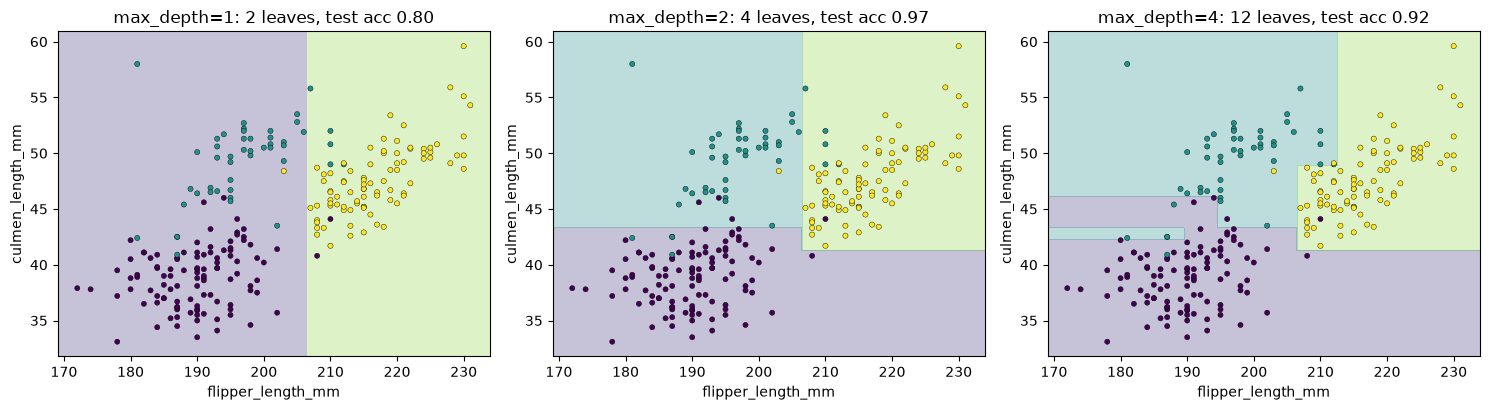

In [3]:
def plot_tree_regions(model, X, y, ax, title, names=pair):
    """Colour the plane by predicted class; works for string labels."""
    classes = np.unique(y)
    pad_x, pad_y = (X[:, 0].max() - X[:, 0].min()) * 0.05, (X[:, 1].max() - X[:, 1].min()) * 0.05
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - pad_x, X[:, 0].max() + pad_x, 300),
                         np.linspace(X[:, 1].min() - pad_y, X[:, 1].max() + pad_y, 300))
    zz = model.predict(np.c_[xx.ravel(), yy.ravel()])
    zz = np.searchsorted(classes, zz).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.3, cmap="viridis", levels=np.arange(-0.5, len(classes) + 0.5))
    ax.scatter(X[:, 0], X[:, 1], c=np.searchsorted(classes, y), cmap="viridis", s=14, edgecolors="k", linewidths=0.3,
               vmin=0, vmax=len(classes) - 1)
    ax.set(title=title, xlabel=names[0], ylabel=names[1])


fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, depth in zip(axes, [1, 2, 4]):
    model = DecisionTreeClassifier(max_depth=depth, random_state=0).fit(X_pg_tr[:, pair_idx], y_pg_tr)
    plot_tree_regions(model, X_pg_tr[:, pair_idx], y_pg_tr, ax,
                      f"max_depth={depth}: {model.get_n_leaves()} leaves, test acc {model.score(X_pg_te[:, pair_idx], y_pg_te):.2f}")
plt.tight_layout()
plt.show()

Each split cuts one box into two with a line **parallel to an axis**; depth *d* allows at most $2^d$ boxes. The model is **piecewise constant**: every point inside a box gets the same prediction.

### ✍️ Your Turn

Fit `DecisionTreeClassifier(max_depth=3, random_state=0)` on **all four** penguin features (`X_pg_tr`, `y_pg_tr`) and store `[number_of_leaves, actual_depth]` in `leaves_and_depth`.

In [4]:
leaves_and_depth = None  # TODO: your code here
_ref = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_pg_tr, y_pg_tr)
check("leaves_and_depth", leaves_and_depth, [_ref.get_n_leaves(), _ref.get_depth()], hint="Use .get_n_leaves() and .get_depth().")

⏳ leaves_and_depth: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
tree3 = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_pg_tr, y_pg_tr)
leaves_and_depth = [tree3.get_n_leaves(), tree3.get_depth()]
_ref = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_pg_tr, y_pg_tr)
check("leaves_and_depth", leaves_and_depth, [_ref.get_n_leaves(), _ref.get_depth()])
```
A depth-3 tree can have up to 8 leaves; it has fewer when a node becomes pure early (no split is needed).
</details>

> 💡 **Interview angle:** "What does a decision tree actually learn?" — a partition of feature space into axis-aligned boxes with a constant prediction per box, found by greedy recursive binary splits. Finding the *optimal* tree is NP-hard, so CART is greedy and never revisits earlier splits.

## 2. Greedy Splits and Thresholds on Continuous Features 🟢

How does the tree pick `flipper_length_mm <= 206.5`? For a continuous feature it:
1. **sorts** the node's rows by that feature,
2. considers a cut **between every pair of consecutive distinct values** (scikit-learn uses the midpoint), so $n_\text{unique}-1$ candidates,
3. computes the weighted child impurity for each candidate, and
4. repeats for every feature and keeps the best (feature, threshold) pair.

Sorting once and sweeping left-to-right with running class counts makes every candidate O(1) to score, so a node costs $O(d\cdot n\log n)$. Let's do step 1–3 by hand for `flipper_length_mm` at the root.

candidate thresholds: 51 (= 52 unique values − 1)
best threshold by hand: 206.5 | weighted child Gini 0.3120 (root Gini 0.6351)
✅ scikit-learn's stump on this feature chose 206.5


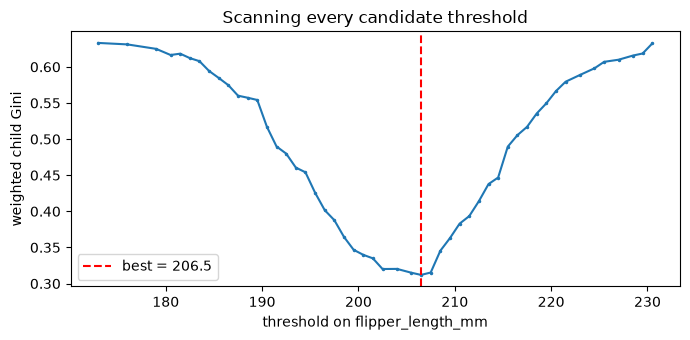

In [5]:
def gini_from_counts(counts):
    counts = np.asarray(counts, dtype=float)
    n = counts.sum(axis=-1, keepdims=True)
    return 1.0 - ((counts / np.maximum(n, 1)) ** 2).sum(axis=-1)


flipper = X_pg_tr[:, peng_features.index("flipper_length_mm")]
classes_pg, y_codes = np.unique(y_pg_tr, return_inverse=True)
order = np.argsort(flipper, kind="stable")
xs, ys = flipper[order], y_codes[order]

left_counts = np.cumsum(np.eye(len(classes_pg))[ys], axis=0)[:-1]          # class counts left of each cut position
right_counts = left_counts[-1] + np.eye(len(classes_pg))[ys[-1]] - left_counts
n_left = np.arange(1, len(xs))
weighted = (n_left * gini_from_counts(left_counts) + (len(xs) - n_left) * gini_from_counts(right_counts)) / len(xs)
valid = xs[1:] > xs[:-1]                                                    # can't cut between equal values
weighted[~valid] = np.inf
best_pos = int(np.argmin(weighted))
best_threshold = (xs[best_pos] + xs[best_pos + 1]) / 2
print(f"candidate thresholds: {valid.sum()} (= {len(np.unique(xs))} unique values − 1)")
print(f"best threshold by hand: {best_threshold} | weighted child Gini {weighted[best_pos]:.4f} (root Gini {gini_from_counts(np.bincount(ys)):.4f})")

sk_stump = DecisionTreeClassifier(max_depth=1).fit(flipper.reshape(-1, 1), y_pg_tr)
assert np.isclose(sk_stump.tree_.threshold[0], best_threshold)
print(f"✅ scikit-learn's stump on this feature chose {sk_stump.tree_.threshold[0]}")

fig, ax = plt.subplots(figsize=(7, 3.5))
cut_points = (xs[:-1] + xs[1:]) / 2
ax.plot(cut_points[valid], weighted[valid], ".-", ms=3)
ax.axvline(best_threshold, color="r", ls="--", label=f"best = {best_threshold}")
ax.set(xlabel="threshold on flipper_length_mm", ylabel="weighted child Gini", title="Scanning every candidate threshold")
ax.legend()
plt.tight_layout()
plt.show()

### ✍️ Your Turn

How many candidate thresholds does the tree consider for `body_mass_g` at the root (training set `X_pg_tr`)? Store the integer in `n_candidates_mass`.

In [6]:
n_candidates_mass = None  # TODO: your code here
check("n_candidates_mass", n_candidates_mass, len(np.unique(X_pg_tr[:, 3])) - 1, hint="Distinct values minus one: np.unique(...).")

⏳ n_candidates_mass: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
mass = X_pg_tr[:, peng_features.index("body_mass_g")]
n_candidates_mass = len(np.unique(mass)) - 1
check("n_candidates_mass", n_candidates_mass, len(np.unique(X_pg_tr[:, 3])) - 1)
```
Continuous features with many distinct values offer many candidate cuts — one reason impurity-based importance favours them (section 10).
</details>

> 💡 **Interview angle:** "How does a tree split a continuous feature efficiently?" — sort the node's values once, sweep candidate cut points between consecutive distinct values while updating class counts (or sums for regression) incrementally, so all thresholds cost $O(n\log n)$ per feature instead of $O(n^2)$. Histogram-based trees (LightGBM, `HistGradientBoosting`) bin values to ~255 buckets to make it $O(n)$.

## 3. Impurity: Gini, Entropy, Log Loss, Information Gain 🟡

[ML Fundamentals, section 12](01_ML_Fundamentals_From_Scratch.ipynb) introduced Gini and entropy. Here we go further. For class proportions $p_k$ in a node:

| Criterion | Formula | Two-class maximum | Notes |
|---|---|---|---|
| **Gini** | $1-\sum_k p_k^2$ | 0.5 | probability two random picks disagree; scikit-learn default; no logarithm |
| **Entropy** | $-\sum_k p_k\log_2 p_k$ | 1 bit | information theory; `criterion="entropy"` |
| **Log loss** | same as entropy (natural log) | | `criterion="log_loss"` — the average log loss of predicting the node's proportions; **identical splits** to entropy |
| Misclassification | $1-\max_k p_k$ | 0.5 | fine for *pruning*, bad for *growing* (see below) |

**Information gain** = parent impurity − weighted average of children's impurity. The tree picks the split with the largest gain.

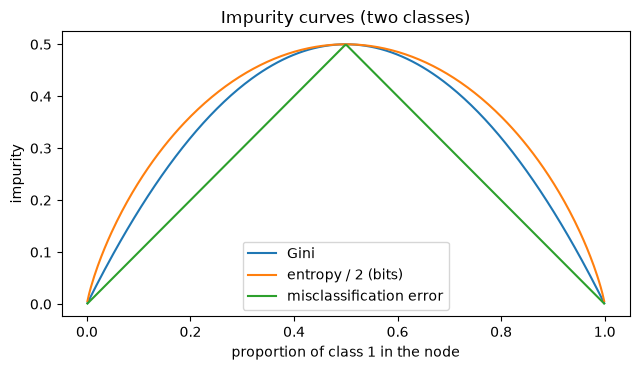

split A: [30,10] | [10,30] → misclassification gain 0.2500 | Gini gain 0.1250 | entropy gain 0.1887
split B: [20,40] | [20,0]  → misclassification gain 0.2500 | Gini gain 0.1667 | entropy gain 0.3113
→ misclassification error can't tell A and B apart; Gini and entropy reward B's pure child (they are strictly concave).


In [7]:
p = np.linspace(0.001, 0.999, 300)
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(p, 1 - p ** 2 - (1 - p) ** 2, label="Gini")
ax.plot(p, -(p * np.log2(p) + (1 - p) * np.log2(1 - p)) / 2, label="entropy / 2 (bits)")
ax.plot(p, 1 - np.maximum(p, 1 - p), label="misclassification error")
ax.set(xlabel="proportion of class 1 in the node", ylabel="impurity", title="Impurity curves (two classes)")
ax.legend()
plt.tight_layout()
plt.show()


def entropy_from_counts(counts):
    counts = np.asarray(counts, dtype=float)
    q = counts / counts.sum(axis=-1, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        return 0.0 - np.where(q > 0, q * np.log2(q), 0.0).sum(axis=-1)


def gain(parent, children, impurity):
    parent = np.asarray(parent, dtype=float)
    children = np.asarray(children, dtype=float)
    weights = children.sum(axis=1) / parent.sum()
    return float(impurity(parent) - (weights * impurity(children)).sum())


parent = [40, 40]
split_a = [[30, 10], [10, 30]]            # two mixed children
split_b = [[20, 40], [20, 0]]             # one pure child
for name, sp in [("A: [30,10] | [10,30]", split_a), ("B: [20,40] | [20,0] ", split_b)]:
    miscls = lambda c: 1 - np.asarray(c, float).max(axis=-1) / np.asarray(c, float).sum(axis=-1)
    print(f"split {name} → misclassification gain {gain(parent, sp, miscls):.4f} | "
          f"Gini gain {gain(parent, sp, gini_from_counts):.4f} | entropy gain {gain(parent, sp, entropy_from_counts):.4f}")
print("→ misclassification error can't tell A and B apart; Gini and entropy reward B's pure child (they are strictly concave).")

`criterion="entropy"` and `criterion="log_loss"` are the same criterion in scikit-learn (entropy in bits and log loss in nats differ only by a constant factor). Let's verify on the penguins, and compare Gini vs entropy trees:

In [8]:
tree_entropy = DecisionTreeClassifier(criterion="entropy", random_state=0).fit(X_pg_tr, y_pg_tr)
tree_logloss = DecisionTreeClassifier(criterion="log_loss", random_state=0).fit(X_pg_tr, y_pg_tr)
same_structure = (np.array_equal(tree_entropy.tree_.feature, tree_logloss.tree_.feature)
                  and np.allclose(tree_entropy.tree_.threshold, tree_logloss.tree_.threshold))
print("entropy and log_loss grow identical trees:", same_structure)

cv_pg = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for crit in ["gini", "entropy"]:
    s = cross_val_score(DecisionTreeClassifier(criterion=crit, max_depth=3, random_state=0), X_peng, y_peng, cv=cv_pg)
    print(f"{crit:8s} depth-3 CV accuracy {s.mean():.3f} ± {s.std():.3f}")
tree_gini = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=0).fit(X_pg_tr, y_pg_tr)
tree_ent3 = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=0).fit(X_pg_tr, y_pg_tr)
print(f"Gini vs entropy depth-3 trees agree on {np.mean(tree_gini.predict(X_pg_te) == tree_ent3.predict(X_pg_te)):.1%} of test penguins")

entropy and log_loss grow identical trees: True
gini     depth-3 CV accuracy 0.950 ± 0.007
entropy  depth-3 CV accuracy 0.947 ± 0.015
Gini vs entropy depth-3 trees agree on 96.1% of test penguins


### ✍️ Your Turn

Compute the **entropy information gain** (in bits) of split B above: parent `[40, 40]`, children `[20, 40]` and `[20, 0]`, using NumPy only (not the `gain` helper). Store it in `info_gain_b`.

In [9]:
info_gain_b = None  # TODO: your code here
check("info_gain_b", info_gain_b, gain([40, 40], [[20, 40], [20, 0]], entropy_from_counts),
      hint="parent entropy = 1 bit; child [20,40] has p = [1/3, 2/3]; weights are 60/80 and 20/80; a pure child has entropy 0.")

⏳ info_gain_b: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
q = np.array([1 / 3, 2 / 3])
h_left = -np.sum(q * np.log2(q))                  # ≈ 0.9183 bits
info_gain_b = 1.0 - (60 / 80 * h_left + 20 / 80 * 0.0)
check("info_gain_b", info_gain_b, gain([40, 40], [[20, 40], [20, 0]], entropy_from_counts))
```
≈ 0.311 bits.
</details>

> 💡 **Interview angle:** "Gini or entropy?" — they pick the same or nearly the same splits in practice (here the depth-3 trees agree on almost every test penguin); Gini avoids the logarithm and is the default; entropy/log loss has an information-theory reading and is identical to `log_loss` in scikit-learn. Misclassification error is avoided for growing because it isn't strictly concave, so it ignores splits that create purer children.

## 4. Regression Trees: Squared, Absolute, and Poisson Criteria 🟡

For a numeric target the node's "impurity" measures how spread out the targets are, and each leaf predicts the constant that minimizes that loss:

| `criterion` | Node impurity | Leaf prediction | Use when |
|---|---|---|---|
| `"squared_error"` (default) | mean squared error around the mean | **mean** | general purpose; fast incremental sums |
| `"absolute_error"` | mean absolute error around the median | **median** | heavy-tailed targets / outliers; slower |
| `"poisson"` | half Poisson deviance | mean (must be > 0) | **counts** (visits, sales, rentals) where variance grows with the mean |

(`"friedman_mse"` is **deprecated in scikit-learn 1.9** — it now maps to `"squared_error"` and will be removed in 1.11.)

The result is a **step function**. On California housing (20,640 real districts), with one feature so we can see it:

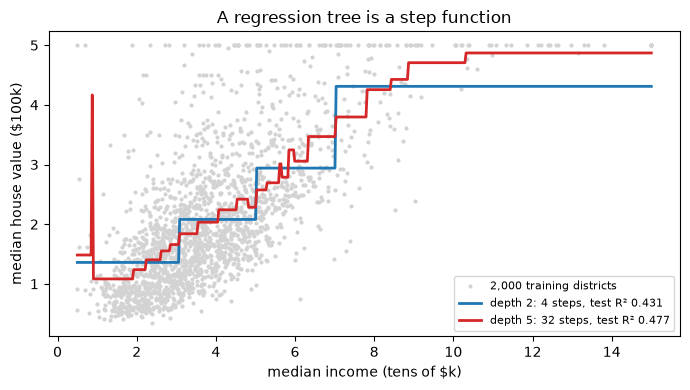

In [10]:
housing = fetch_california_housing(data_home=DATA_HOME)
X_h, y_h = housing.data, housing.target                      # target: median house value in $100k
X_h_tr, X_h_te, y_h_tr, y_h_te = train_test_split(X_h, y_h, test_size=0.25, random_state=SEED)
medinc = housing.feature_names.index("MedInc")

grid_inc = np.linspace(X_h_tr[:, medinc].min(), X_h_tr[:, medinc].max(), 500).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(7, 4))
sample = np.random.default_rng(0).choice(len(y_h_tr), 2000, replace=False)
ax.scatter(X_h_tr[sample, medinc], y_h_tr[sample], s=4, color="lightgray", label="2,000 training districts")
for depth, color in [(2, "#1f77b4"), (5, "#d62728")]:
    step_tree = DecisionTreeRegressor(max_depth=depth, random_state=0).fit(X_h_tr[:, [medinc]], y_h_tr)
    ax.plot(grid_inc[:, 0], step_tree.predict(grid_inc), color=color, lw=2,
            label=f"depth {depth}: {step_tree.get_n_leaves()} steps, test R² {step_tree.score(X_h_te[:, [medinc]], y_h_te):.3f}")
ax.set(xlabel="median income (tens of $k)", ylabel="median house value ($100k)", title="A regression tree is a step function")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Verify the leaf rule.** `apply()` returns the leaf index of each row; a leaf's prediction should be the **mean** of its training targets for squared error and the **median** for absolute error.

In [11]:
reg_sq = DecisionTreeRegressor(criterion="squared_error", max_depth=4, random_state=0).fit(X_h_tr, y_h_tr)
reg_abs = DecisionTreeRegressor(criterion="absolute_error", max_depth=4, random_state=0).fit(X_h_tr, y_h_tr)
for name, model, stat in [("squared_error", reg_sq, np.mean), ("absolute_error", reg_abs, np.median)]:
    leaves = model.apply(X_h_tr)
    ok = all(np.isclose(model.tree_.value[leaf].item(), stat(y_h_tr[leaves == leaf])) for leaf in np.unique(leaves))
    print(f"{name:15s} leaves predict the {stat.__name__} of their training targets: {ok} | "
          f"test MAE {mean_absolute_error(y_h_te, model.predict(X_h_te)):.3f} | test RMSE {np.sqrt(mean_squared_error(y_h_te, model.predict(X_h_te))):.3f}")

squared_error   leaves predict the mean of their training targets: True | test MAE 0.557 | test RMSE 0.757
absolute_error  leaves predict the median of their training targets: True | test MAE 0.548 | test RMSE 0.771


**Poisson on real counts.** The UCI bike-sharing data counts rentals per hour (17,379 hours). Counts are non-negative and noisier when the average is high — the Poisson criterion's assumption. We compare criteria on a held-out set with the metric that matches counts, the **mean Poisson deviance** (lower is better), plus MAE.

In [12]:
bike = fetch_openml("Bike_Sharing_Demand", version=2, as_frame=True, data_home=DATA_HOME)
X_bike = bike.data.copy()
for col in X_bike.select_dtypes("category").columns:
    X_bike[col] = X_bike[col].cat.codes                      # trees accept integer codes (section 9 discusses encodings)
y_bike = bike.target.to_numpy(dtype=float)
X_bk_tr, X_bk_te, y_bk_tr, y_bk_te = train_test_split(X_bike, y_bike, test_size=0.25, random_state=SEED)
print(f"rentals per hour: mean {y_bike.mean():.0f}, variance {y_bike.var():.0f}, zeros {int((y_bike == 0).sum())}")

crit_rows = []
for crit in ["squared_error", "poisson", "absolute_error"]:
    start = time.perf_counter()
    bike_tree = DecisionTreeRegressor(criterion=crit, min_samples_leaf=20, random_state=0).fit(X_bk_tr, y_bk_tr)
    fit_s = time.perf_counter() - start
    pred = bike_tree.predict(X_bk_te)
    crit_rows.append({"criterion": crit, "fit s": fit_s, "leaves": bike_tree.get_n_leaves(),
                      "Poisson deviance": mean_poisson_deviance(y_bk_te, np.maximum(pred, 1e-9)),
                      "MAE": mean_absolute_error(y_bk_te, pred), "min prediction": pred.min()})
crit_df = pd.DataFrame(crit_rows).round(3)
print(crit_df.to_string(index=False))
print(f"\nlowest Poisson deviance: {crit_df.loc[crit_df['Poisson deviance'].idxmin(), 'criterion']} | "
      f"lowest MAE: {crit_df.loc[crit_df['MAE'].idxmin(), 'criterion']} | slowest fit: {crit_df.loc[crit_df['fit s'].idxmax(), 'criterion']}")
print("A tree's leaf is a constant either way, so criteria often land close; the choice matters more in boosting and with log-link models.")

rentals per hour: mean 189, variance 32900, zeros 0


     criterion  fit s  leaves  Poisson deviance    MAE  min prediction
 squared_error  0.025     493            16.144 35.967           1.586
       poisson  0.019     499            16.005 36.190           1.586
absolute_error  0.174     500            17.394 36.076           1.000

lowest Poisson deviance: poisson | lowest MAE: squared_error | slowest fit: absolute_error
A tree's leaf is a constant either way, so criteria often land close; the choice matters more in boosting and with log-link models.


### ✍️ Your Turn

Using `reg_sq`, find the leaf of the **first test district** (`X_h_te[:1]`) with `apply`, then compute the mean of the **training** targets in that leaf. Store it in `leaf_mean_first`.

In [13]:
leaf_mean_first = None  # TODO: your code here
check("leaf_mean_first", leaf_mean_first, reg_sq.predict(X_h_te[:1])[0], hint="leaf = reg_sq.apply(X_h_te[:1])[0]; compare with reg_sq.apply(X_h_tr).")

⏳ leaf_mean_first: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
leaf = reg_sq.apply(X_h_te[:1])[0]
leaf_mean_first = y_h_tr[reg_sq.apply(X_h_tr) == leaf].mean()
check("leaf_mean_first", leaf_mean_first, reg_sq.predict(X_h_te[:1])[0])
```
Prediction = look up the leaf, return its stored constant. This is also why regression trees **cannot extrapolate** (Pitfall 3).
</details>

> 💡 **Interview angle:** "How does a regression tree choose splits?" — it minimizes the weighted squared error of the children (equivalently maximizes $\frac{S_L^2}{n_L}+\frac{S_R^2}{n_R}$ with running target sums $S$), and each leaf predicts the mean. Use `absolute_error` (median leaves) for outlier-heavy targets and `poisson` for non-negative counts.

## 5. Overfitting: a Fully Grown Tree 🟢

With no limits, a tree keeps splitting until every leaf is pure (or cannot be split), so it can **memorize** the training data. We switch to the **Titanic** passenger list (1,309 real passengers; target: survived). Missing `age`/`fare`/`embarked` values stay as `NaN` — scikit-learn's trees handle them natively (section 9).

In [14]:
titanic = fetch_openml("titanic", version=1, as_frame=True, data_home=DATA_HOME).frame
tit_features = ["pclass", "is_female", "age", "sibsp", "parch", "fare", "embarked"]
X_tit = pd.DataFrame({
    "pclass": titanic["pclass"].astype(float),
    "is_female": (titanic["sex"] == "female").astype(float),
    "age": titanic["age"],
    "sibsp": titanic["sibsp"].astype(float),
    "parch": titanic["parch"].astype(float),
    "fare": titanic["fare"],
    "embarked": titanic["embarked"].map({"C": 0.0, "Q": 1.0, "S": 2.0}).astype(float),   # port code; NaN stays NaN
})
y_tit = titanic["survived"].astype(int).to_numpy()
print(f"{len(X_tit)} passengers | survival rate {y_tit.mean():.3f} | missing values: {X_tit.isna().sum()[X_tit.isna().sum() > 0].to_dict()}")

X_t_tr, X_t_te, y_t_tr, y_t_te = train_test_split(X_tit, y_tit, test_size=0.25, stratify=y_tit, random_state=SEED)
cv_t = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

full_tree = DecisionTreeClassifier(random_state=0).fit(X_t_tr, y_t_tr)
leaf_sizes = full_tree.tree_.n_node_samples[full_tree.tree_.children_left == -1]
print(f"fully grown tree: depth {full_tree.get_depth()}, {full_tree.get_n_leaves()} leaves for {len(y_t_tr)} passengers")
print(f"train accuracy {full_tree.score(X_t_tr, y_t_tr):.3f} | test accuracy {full_tree.score(X_t_te, y_t_te):.3f}")
print(f"{np.mean(leaf_sizes == 1):.0%} of leaves contain a single training passenger — each is a rule that describes one person, not a pattern")

1309 passengers | survival rate 0.382 | missing values: {'age': 263, 'fare': 1, 'embarked': 2}
fully grown tree: depth 20, 239 leaves for 981 passengers
train accuracy 0.972 | test accuracy 0.765
41% of leaves contain a single training passenger — each is a rule that describes one person, not a pattern


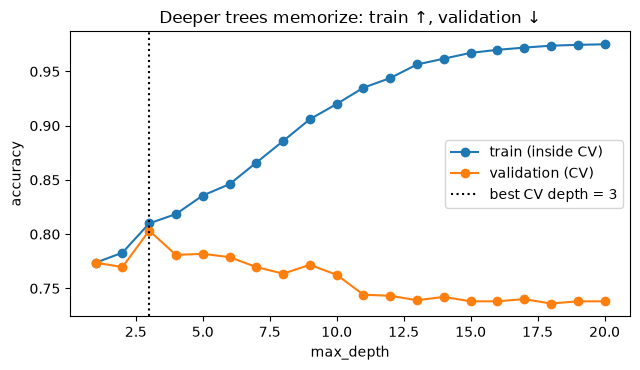

best CV accuracy 0.803 at depth 3; at depth 20 train 0.975 vs CV 0.738


In [15]:
depths = range(1, 21)
train_acc, cv_acc = [], []
for depth in depths:
    res = cross_validate(DecisionTreeClassifier(max_depth=depth, random_state=0), X_t_tr, y_t_tr, cv=cv_t, return_train_score=True)
    train_acc.append(res["train_score"].mean())
    cv_acc.append(res["test_score"].mean())
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(depths, train_acc, "o-", label="train (inside CV)")
ax.plot(depths, cv_acc, "o-", label="validation (CV)")
best_depth = list(depths)[int(np.argmax(cv_acc))]
ax.axvline(best_depth, color="k", ls=":", label=f"best CV depth = {best_depth}")
ax.set(xlabel="max_depth", ylabel="accuracy", title="Deeper trees memorize: train ↑, validation ↓")
ax.legend()
plt.tight_layout()
plt.show()
print(f"best CV accuracy {max(cv_acc):.3f} at depth {best_depth}; at depth 20 train {train_acc[-1]:.3f} vs CV {cv_acc[-1]:.3f}")

> 💡 **Interview angle:** "Why do decision trees overfit?" — they are extremely flexible (low bias): with enough depth every training row gets its own leaf, so leaves fit noise. Each split also sees fewer rows, so deep split choices are statistically unreliable. Control complexity with depth/leaf-size limits or pruning, or average many trees (random forests).

## 6. Stopping Criteria (Pre-Pruning) 🟡

**Pre-pruning** stops growth early. Each knob answers a different question:

| Hyperparameter | Stops splitting when… | Typical range |
|---|---|---|
| `max_depth` | the path is already this long | 2–12 |
| `min_samples_split` | the node has fewer rows than this | 2–50 |
| `min_samples_leaf` | a child would get fewer rows than this (smooths leaves; usually the most useful) | 1–50, or a fraction like 0.01 |
| `min_impurity_decrease` | the weighted impurity decrease $\frac{n_t}{n}\big(I_t - \frac{n_L}{n_t}I_L - \frac{n_R}{n_t}I_R\big)$ is below this | 0–0.01 |
| `max_leaf_nodes` | this many leaves exist — grows **best-first** (largest improvement first) instead of depth-first | 8–256 |

Validation curves on the Titanic training set (same 5 folds for every knob):

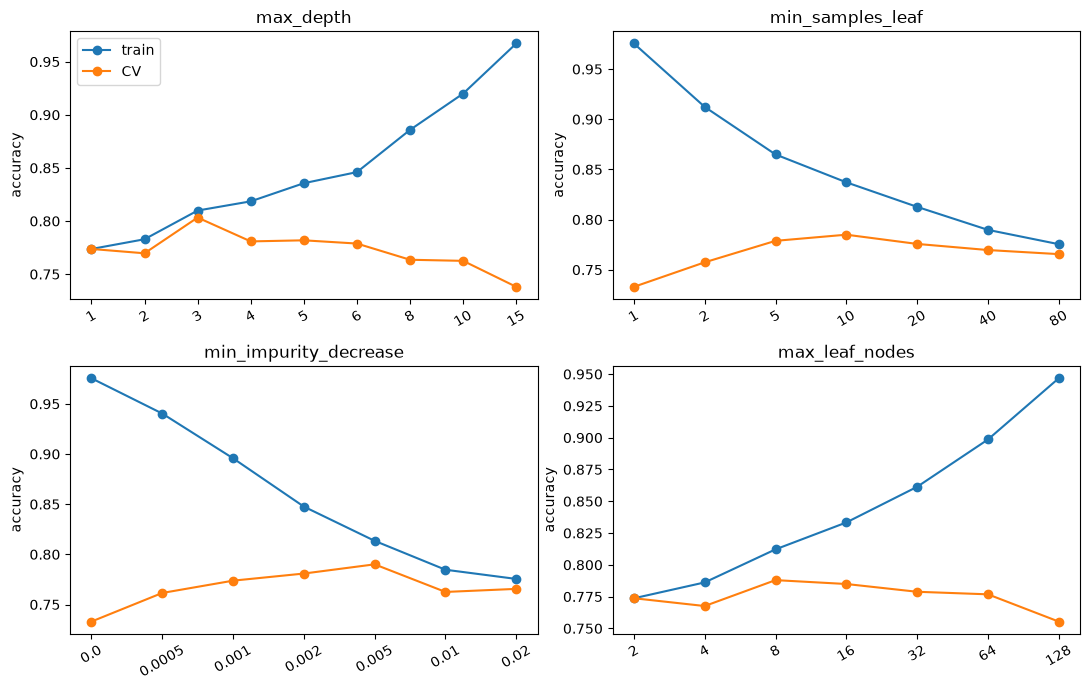

max_depth              best = 3       → CV accuracy 0.803
min_samples_leaf       best = 10      → CV accuracy 0.785
min_impurity_decrease  best = 0.005   → CV accuracy 0.790
max_leaf_nodes         best = 8       → CV accuracy 0.788


In [16]:
knobs = {
    "max_depth": [1, 2, 3, 4, 5, 6, 8, 10, 15],
    "min_samples_leaf": [1, 2, 5, 10, 20, 40, 80],
    "min_impurity_decrease": [0.0, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02],
    "max_leaf_nodes": [2, 4, 8, 16, 32, 64, 128],
}
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
knob_best = {}
for ax, (param, values) in zip(axes.ravel(), knobs.items()):
    tr_scores, va_scores = validation_curve(DecisionTreeClassifier(random_state=0), X_t_tr, y_t_tr,
                                            param_name=param, param_range=values, cv=cv_t)
    xs_plot = np.arange(len(values))
    ax.plot(xs_plot, tr_scores.mean(axis=1), "o-", label="train")
    ax.plot(xs_plot, va_scores.mean(axis=1), "o-", label="CV")
    ax.set_xticks(xs_plot, [str(v) for v in values], rotation=30)
    ax.set(title=param, ylabel="accuracy")
    best_i = int(np.argmax(va_scores.mean(axis=1)))
    knob_best[param] = (values[best_i], va_scores.mean(axis=1)[best_i])
axes[0, 0].legend()
plt.tight_layout()
plt.show()
for param, (value, score) in knob_best.items():
    print(f"{param:22s} best = {value!s:7s} → CV accuracy {score:.3f}")

**Sensible defaults to start from:** `min_samples_leaf` ≈ 5–20 (or ~1% of rows), `max_depth` 4–8 for an interpretable tree, then let cost-complexity pruning or CV settle the rest. Note how every knob reaches a similar best CV score — they are different ways to limit the same complexity.

### ✍️ Your Turn

Fit `DecisionTreeClassifier(max_leaf_nodes=8, random_state=0)` on the Titanic training set. How many leaves does it have, and what is its depth? Store `[n_leaves, depth]` in `best_first_shape`. (Best-first growth doesn't have to be balanced.)

In [17]:
best_first_shape = None  # TODO: your code here
_bf = DecisionTreeClassifier(max_leaf_nodes=8, random_state=0).fit(X_t_tr, y_t_tr)
check("best_first_shape", best_first_shape, [_bf.get_n_leaves(), _bf.get_depth()], hint="get_n_leaves() and get_depth() on the fitted tree.")

⏳ best_first_shape: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
tree_bf = DecisionTreeClassifier(max_leaf_nodes=8, random_state=0).fit(X_t_tr, y_t_tr)
best_first_shape = [tree_bf.get_n_leaves(), tree_bf.get_depth()]
_bf = DecisionTreeClassifier(max_leaf_nodes=8, random_state=0).fit(X_t_tr, y_t_tr)
check("best_first_shape", best_first_shape, [_bf.get_n_leaves(), _bf.get_depth()])
```
Eight leaves with depth greater than 3 means the tree spent its splits where they helped most, not evenly — exactly how LightGBM's leaf-wise growth works.
</details>

> 💡 **Interview angle:** "Which tree hyperparameters would you tune first?" — `min_samples_leaf` (or `max_leaf_nodes`) and `max_depth`, on a CV grid; they all control variance. `min_impurity_decrease` is scale-dependent and less intuitive. For ensembles the answer changes: random forests like deep trees, boosting likes shallow ones.

## 7. Cost-Complexity Pruning with ccp_alpha 🔴

**Post-pruning** grows a big tree, then cuts it back. CART's **minimal cost-complexity pruning** scores a subtree $T$ by

$$R_\alpha(T) = R(T) + \alpha\,\lvert \tilde T\rvert$$

where $R(T)$ is the total weighted impurity of the leaves and $\lvert\tilde T\rvert$ the number of leaves. For every internal node $t$, the **effective alpha**

$$g(t) = \frac{R(t) - R(T_t)}{\lvert\tilde T_t\rvert - 1}$$

is the price per removed leaf at which collapsing $t$'s subtree into a leaf stops hurting. **Weakest-link pruning** repeatedly collapses the node with the smallest $g(t)$, giving a nested sequence of trees and the list of alphas `cost_complexity_pruning_path` returns. Then **cross-validation picks alpha**.

First, verify the formula: the smallest $g(t)$ in the full tree must equal the first non-zero alpha on scikit-learn's path.

In [18]:
path = DecisionTreeClassifier(random_state=0).cost_complexity_pruning_path(X_t_tr, y_t_tr)
ccp_alphas, leaf_impurities = path.ccp_alphas, path.impurities

t = full_tree.tree_
n_total = t.n_node_samples[0]
R_node = t.impurity * t.n_node_samples / n_total                 # R(t): node's weighted impurity if it were a leaf
R_sub, n_leaves_sub = np.zeros(t.node_count), np.zeros(t.node_count)
for node in range(t.node_count - 1, -1, -1):                     # children always have larger ids than parents
    if t.children_left[node] == -1:
        R_sub[node], n_leaves_sub[node] = R_node[node], 1
    else:
        l, r = t.children_left[node], t.children_right[node]
        R_sub[node], n_leaves_sub[node] = R_sub[l] + R_sub[r], n_leaves_sub[l] + n_leaves_sub[r]
internal = t.children_left != -1
g = (R_node[internal] - R_sub[internal]) / (n_leaves_sub[internal] - 1)
first_positive_alpha = ccp_alphas[ccp_alphas > 1e-12][0]
print(f"smallest effective alpha by hand: {g.min():.6f} | first non-zero alpha from sklearn: {first_positive_alpha:.6f}")
assert np.isclose(g.min(), first_positive_alpha)
print(f"✅ weakest-link formula verified | path has {len(ccp_alphas)} alphas, from {ccp_alphas[0]:.4f} to {ccp_alphas[-1]:.4f} (the last one prunes to the root)")

smallest effective alpha by hand: 0.000024 | first non-zero alpha from sklearn: 0.000024
✅ weakest-link formula verified | path has 101 alphas, from 0.0000 to 0.1250 (the last one prunes to the root)


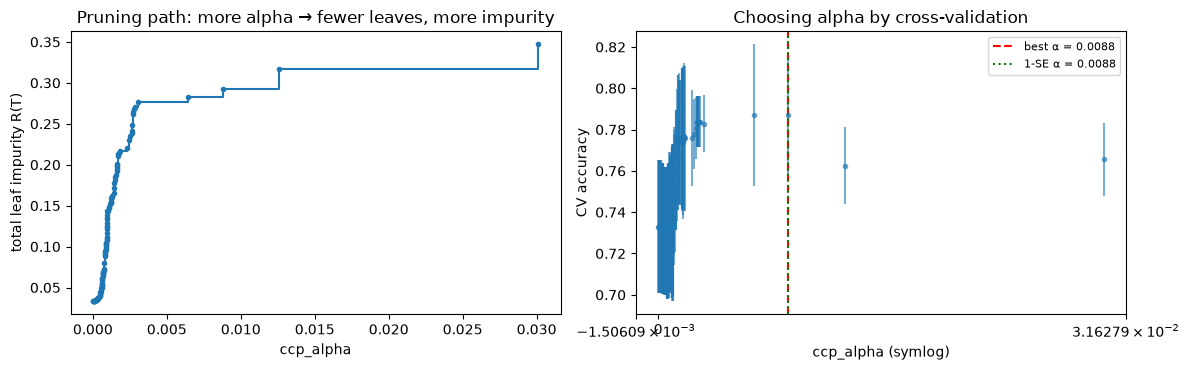

full tree      leaves  239 | CV acc 0.733 | test acc 0.765
best-CV alpha  leaves    5 | CV acc 0.787 | test acc 0.805
1-SE alpha     leaves    5 | CV acc 0.787 | test acc 0.805


In [19]:
alpha_candidates = ccp_alphas[:-1]                               # drop the alpha that leaves only the root
alpha_rows = []
for a in alpha_candidates:
    scores = cross_val_score(DecisionTreeClassifier(random_state=0, ccp_alpha=a), X_t_tr, y_t_tr, cv=cv_t)
    alpha_rows.append({"alpha": a, "cv_mean": scores.mean(), "cv_std": scores.std(),
                       "leaves": DecisionTreeClassifier(random_state=0, ccp_alpha=a).fit(X_t_tr, y_t_tr).get_n_leaves()})
alpha_df = pd.DataFrame(alpha_rows)
best_row = alpha_df.loc[alpha_df["cv_mean"].idxmax()]
one_se_limit = best_row["cv_mean"] - best_row["cv_std"] / np.sqrt(cv_t.get_n_splits())
alpha_1se = alpha_df.loc[alpha_df["cv_mean"] >= one_se_limit, "alpha"].max()           # simplest tree within 1 standard error

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(ccp_alphas[:-1], leaf_impurities[:-1], marker=".", drawstyle="steps-post")
axes[0].set(xlabel="ccp_alpha", ylabel="total leaf impurity R(T)", title="Pruning path: more alpha → fewer leaves, more impurity")
axes[1].errorbar(alpha_df["alpha"], alpha_df["cv_mean"], yerr=alpha_df["cv_std"], fmt=".", alpha=0.6)
axes[1].axvline(best_row["alpha"], color="r", ls="--", label=f"best α = {best_row['alpha']:.4f}")
axes[1].axvline(alpha_1se, color="g", ls=":", label=f"1-SE α = {alpha_1se:.4f}")
axes[1].set(xscale="symlog", xlabel="ccp_alpha (symlog)", ylabel="CV accuracy", title="Choosing alpha by cross-validation")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

pruned_best = DecisionTreeClassifier(random_state=0, ccp_alpha=best_row["alpha"]).fit(X_t_tr, y_t_tr)
pruned_1se = DecisionTreeClassifier(random_state=0, ccp_alpha=alpha_1se).fit(X_t_tr, y_t_tr)
for name, model, cvm in [("full tree", full_tree, alpha_df["cv_mean"].iloc[0]), ("best-CV alpha", pruned_best, best_row["cv_mean"]),
                         ("1-SE alpha", pruned_1se, alpha_df.loc[alpha_df["alpha"] == alpha_1se, "cv_mean"].item())]:
    print(f"{name:14s} leaves {model.get_n_leaves():4d} | CV acc {cvm:.3f} | test acc {model.score(X_t_te, y_t_te):.3f}")

> 💡 **Interview angle:** "Pre-pruning or post-pruning?" — pre-pruning is cheap but short-sighted (a weak split can enable a great one below it); cost-complexity post-pruning grows the full tree and removes the weakest links, choosing α by CV — often with the **1-standard-error rule** to prefer the simplest tree whose score is statistically indistinguishable from the best.

## 8. Reading a Tree: plot_tree, export_text, decision_path 🟢

A shallow tree is a model you can **read aloud**. We use the 1-SE pruned Titanic tree.

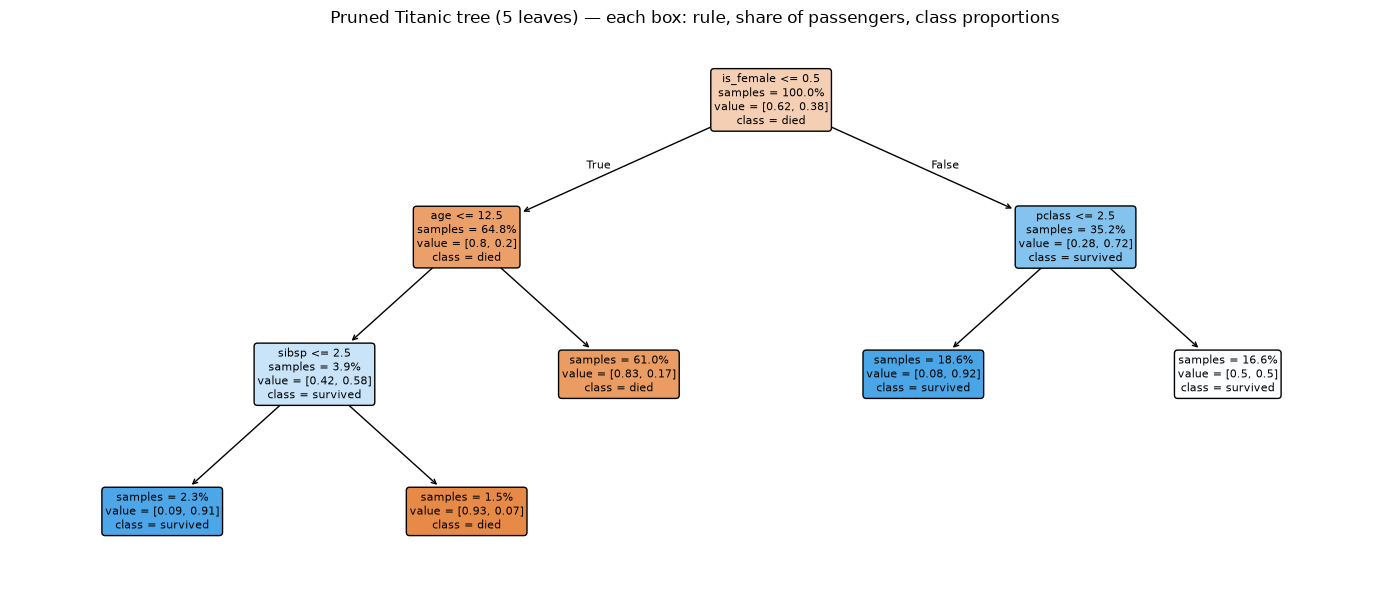

|--- is_female <= 0.5
|   |--- age <= 12.5
|   |   |--- sibsp <= 2.5
|   |   |   |--- weights: [2.0, 21.0] class: survived
|   |   |--- sibsp >  2.5
|   |   |   |--- weights: [14.0, 1.0] class: died
|   |--- age >  12.5
|   |   |--- weights: [494.0, 104.0] class: died
|--- is_female >  0.5
|   |--- pclass <= 2.5
|   |   |--- weights: [15.0, 167.0] class: survived
|   |--- pclass >  2.5
|   |   |--- weights: [81.0, 82.0] class: survived



In [20]:
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(pruned_1se, feature_names=tit_features, class_names=["died", "survived"], filled=True, rounded=True,
          impurity=False, proportion=True, precision=2, fontsize=8, ax=ax)
ax.set_title(f"Pruned Titanic tree ({pruned_1se.get_n_leaves()} leaves) — each box: rule, share of passengers, class proportions")
plt.tight_layout()
plt.show()

print(export_text(pruned_1se, feature_names=tit_features, class_names=["died", "survived"], show_weights=True, decimals=1))

`decision_path` tells you **which rules fired for one passenger** — a per-prediction explanation:

In [21]:
def explain(model, row, names):
    node_ids = model.decision_path(row).indices
    t_ = model.tree_
    for node in node_ids:
        if t_.children_left[node] == -1:
            proba = t_.value[node][0]
            print(f"  → leaf {node}: P(survived) = {proba[1]:.2f} ({t_.n_node_samples[node]} training passengers)")
        else:
            f, thr = t_.feature[node], t_.threshold[node]
            value = row.iloc[0, f]
            if pd.isna(value):
                went = "left" if t_.missing_go_to_left[node] else "right"
                print(f"  {names[f]} is missing → goes {went} (learned during training)")
            else:
                print(f"  {names[f]} = {value:g} {'<=' if value <= thr else '>'} {thr:.2f}")


passenger = X_t_te.iloc[[0]]
print(f"passenger: {passenger.iloc[0].to_dict()} | truly survived: {bool(y_t_te[0])}")
explain(pruned_1se, passenger, tit_features)

passenger: {'pclass': 3.0, 'is_female': 0.0, 'age': nan, 'sibsp': 8.0, 'parch': 2.0, 'fare': 69.55, 'embarked': 2.0} | truly survived: False
  is_female = 0 <= 0.50
  age is missing → goes right (learned during training)
  → leaf 5: P(survived) = 0.17 (598 training passengers)


### ✍️ Your Turn

How many nodes (root and leaf included) does the **second** test passenger `X_t_te.iloc[[1]]` visit in `pruned_1se`? Store the integer in `n_nodes_visited`.

In [22]:
n_nodes_visited = None  # TODO: your code here
check("n_nodes_visited", n_nodes_visited, int(pruned_1se.decision_path(X_t_te.iloc[[1]]).sum()),
      hint="decision_path returns a sparse indicator matrix: one row per sample, a 1 for each node visited.")

⏳ n_nodes_visited: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_nodes_visited = int(pruned_1se.decision_path(X_t_te.iloc[[1]]).sum())
check("n_nodes_visited", n_nodes_visited, int(pruned_1se.decision_path(X_t_te.iloc[[1]]).sum()))
```
That count is the passenger's leaf depth + 1.
</details>

> 💡 **Interview angle:** "How would you explain a tree's prediction to a stakeholder?" — show the path of rules that fired (`decision_path`) and the leaf's training class proportions and sample size. Keep the tree shallow enough to read; if you need a deep tree or an ensemble, switch to SHAP (see [18 · Model Interpretability](18_Model_Interpretability_SHAP_LIME.ipynb)).

## 9. Missing Values and Categorical Features 🟡

### Missing values: native support (verified in the installed version)
Since scikit-learn 1.3, `DecisionTreeClassifier`/`DecisionTreeRegressor` accept `NaN` in dense inputs. While searching a split on a feature with missing values, the splitter tries sending all missing rows **left** and **right** and keeps whichever is better; the choice is stored per node in `tree_.missing_go_to_left`. If a feature had **no** missing values in training, a `NaN` at prediction time goes to the child that received **more training samples**. Let's verify every claim instead of trusting it.

In [23]:
support_rows = []
for est_name, Est, criteria, target in [("DecisionTreeClassifier", DecisionTreeClassifier, ["gini", "entropy", "log_loss"], y_t_tr),
                                        ("DecisionTreeRegressor", DecisionTreeRegressor, ["squared_error", "absolute_error", "poisson"], y_t_tr + 1.0)]:
    for crit in criteria:
        for splitter in ["best", "random"]:
            try:
                Est(criterion=crit, splitter=splitter, max_depth=3, random_state=0).fit(X_t_tr, target)
                status = "✅ fits with NaN"
            except ValueError as err:
                status = f"❌ {str(err)[:60]}"
            support_rows.append({"estimator": est_name, "criterion": crit, "splitter": splitter, "NaN in X": status})
print(pd.DataFrame(support_rows).to_string(index=False))

             estimator      criterion splitter        NaN in X
DecisionTreeClassifier           gini     best ✅ fits with NaN
DecisionTreeClassifier           gini   random ✅ fits with NaN
DecisionTreeClassifier        entropy     best ✅ fits with NaN
DecisionTreeClassifier        entropy   random ✅ fits with NaN
DecisionTreeClassifier       log_loss     best ✅ fits with NaN
DecisionTreeClassifier       log_loss   random ✅ fits with NaN
 DecisionTreeRegressor  squared_error     best ✅ fits with NaN
 DecisionTreeRegressor  squared_error   random ✅ fits with NaN
 DecisionTreeRegressor absolute_error     best ✅ fits with NaN
 DecisionTreeRegressor absolute_error   random ✅ fits with NaN
 DecisionTreeRegressor        poisson     best ✅ fits with NaN
 DecisionTreeRegressor        poisson   random ✅ fits with NaN


In [24]:
nan_tree = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_t_tr, y_t_tr)
tn = nan_tree.tree_
age_nodes = np.flatnonzero((tn.feature == tit_features.index("age")) & (tn.children_left != -1))
for node in age_nodes:
    side = "left (≤)" if tn.missing_go_to_left[node] else "right (>)"
    print(f"node {node}: age <= {tn.threshold[node]:.2f} → passengers with missing age go {side}")

# A tree trained WITHOUT missing values still accepts NaN at prediction time: it goes to the bigger child.
imputed_tr = X_t_tr.fillna(X_t_tr.median())
no_nan_tree = DecisionTreeClassifier(max_depth=3, random_state=0).fit(imputed_tr, y_t_tr)
tt_ = no_nan_tree.tree_
root_feature = tit_features[tt_.feature[0]]
probe_row = imputed_tr.iloc[[0]].copy()
probe_row[root_feature] = np.nan
visited = set(no_nan_tree.decision_path(probe_row).indices)
bigger_child = tt_.children_left[0] if tt_.n_node_samples[tt_.children_left[0]] > tt_.n_node_samples[tt_.children_right[0]] else tt_.children_right[0]
assert bigger_child in visited
print(f"\n✅ NaN in root feature '{root_feature}' (never missing in training) was routed to the bigger child "
      f"({tt_.n_node_samples[bigger_child]} of {tt_.n_node_samples[0]} training rows). Silent — so monitor missingness in production.")

node 1: age <= 12.50 → passengers with missing age go right (>)

✅ NaN in root feature 'is_female' (never missing in training) was routed to the bigger child (636 of 981 training rows). Silent — so monitor missingness in production.


Is native handling better than imputing? Compare on the same folds (the imputer is fitted inside each fold):

In [25]:
nan_options = {
    "native NaN support": DecisionTreeClassifier(max_depth=4, random_state=0),
    "median imputation": make_pipeline(SimpleImputer(strategy="median"), DecisionTreeClassifier(max_depth=4, random_state=0)),
    "median + missing indicator": make_pipeline(SimpleImputer(strategy="median", add_indicator=True), DecisionTreeClassifier(max_depth=4, random_state=0)),
}
for name, est in nan_options.items():
    s = cross_val_score(est, X_t_tr, y_t_tr, cv=cv_t)
    print(f"{name:28s} CV accuracy {s.mean():.3f} ± {s.std():.3f}")

native NaN support           CV accuracy 0.781 ± 0.023
median imputation            CV accuracy 0.785 ± 0.028
median + missing indicator   CV accuracy 0.785 ± 0.028


### Categorical features: **no** native support in `DecisionTree*`

Verified below: the tree constructors have no `categorical_features` parameter, and string columns raise an error. (`HistGradientBoostingClassifier` *does* support categories natively — see [10 · Gradient Boosting](10_Gradient_Boosting.ipynb).) So we encode inside a pipeline:

| Encoding | What the tree sees | Good for |
|---|---|---|
| `OrdinalEncoder` | one integer column per feature; order is arbitrary, but repeated splits can still isolate categories | many categories, compact trees |
| `OneHotEncoder` | one 0/1 column per category; each split isolates **one** category | few categories, readable rules ("embarked_S = 1") |

In [26]:
params = inspect.signature(DecisionTreeClassifier).parameters
print("DecisionTreeClassifier has 'categorical_features':", "categorical_features" in params)
print("HistGradientBoostingClassifier has 'categorical_features':", "categorical_features" in inspect.signature(HistGradientBoostingClassifier).parameters)

raw_cols = ["pclass", "sex", "embarked", "age", "sibsp", "parch", "fare"]
X_raw_tit = titanic[raw_cols]
X_raw_tr, X_raw_te = X_raw_tit.loc[X_t_tr.index], X_raw_tit.loc[X_t_te.index]
try:
    DecisionTreeClassifier().fit(X_raw_tr, y_t_tr)
except ValueError as err:
    print("raw string column →", type(err).__name__ + ":", str(err)[:70])

cat_cols, num_cols = ["pclass", "sex", "embarked"], ["age", "sibsp", "parch", "fare"]
encoders = {
    "OrdinalEncoder": make_column_transformer(
        (OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=np.nan), cat_cols),
        ("passthrough", num_cols), verbose_feature_names_out=False),
    "OneHotEncoder": make_column_transformer(
        (OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("passthrough", num_cols), verbose_feature_names_out=False),
}
for name, ct in encoders.items():
    pipe = make_pipeline(ct, DecisionTreeClassifier(max_depth=4, random_state=0))
    s = cross_val_score(pipe, X_raw_tr, y_t_tr, cv=cv_t)
    n_out = ct.fit(X_raw_tr).get_feature_names_out().shape[0]
    print(f"{name:15s} → {n_out:2d} columns | CV accuracy {s.mean():.3f} ± {s.std():.3f}")

DecisionTreeClassifier has 'categorical_features': False
HistGradientBoostingClassifier has 'categorical_features': True
raw string column → ValueError: could not convert string to float: 'female'
OrdinalEncoder  →  7 columns | CV accuracy 0.781 ± 0.023
OneHotEncoder   → 12 columns | CV accuracy 0.781 ± 0.023


### ✍️ Your Turn

How many columns does the **one-hot** column transformer produce for `pclass` alone (fitted on `X_raw_tr`)? Store the integer in `n_pclass_columns`.

In [27]:
n_pclass_columns = None  # TODO: your code here
check("n_pclass_columns", n_pclass_columns, X_raw_tr["pclass"].nunique(), hint="One column per distinct class value — or count names starting with 'pclass_' in get_feature_names_out().")

⏳ n_pclass_columns: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
names_out = encoders["OneHotEncoder"].fit(X_raw_tr).get_feature_names_out()
n_pclass_columns = sum(name.startswith("pclass_") for name in names_out)
check("n_pclass_columns", n_pclass_columns, X_raw_tr["pclass"].nunique())
```
</details>

> 💡 **Interview angle:** "How do trees handle missing values and categoricals?" — in scikit-learn ≥ 1.3, NaNs are routed to the better side at each split (learned), and unseen NaNs go to the larger child; categoricals must be encoded (ordinal or one-hot) because `DecisionTree*` has no native categorical splits — unlike LightGBM, CatBoost, and `HistGradientBoosting`. Always check your library version's docs: this changed recently.

## 10. Feature Importance: Impurity Bias vs Permutation 🔴

`feature_importances_` is **MDI** (mean decrease in impurity): the total impurity decrease from splits on each feature, weighted by the rows reaching them. It is computed on the **training** data, so it rewards features the tree **used to overfit** — and features with many distinct values offer many more candidate thresholds to overfit with.

**Experiment:** add two columns of pure noise to Titanic — `random_id` (1,000 possible values, high cardinality) and `random_coin` (0/1) — then compare MDI with **permutation importance on the test set** (how much the score drops when a column is shuffled).

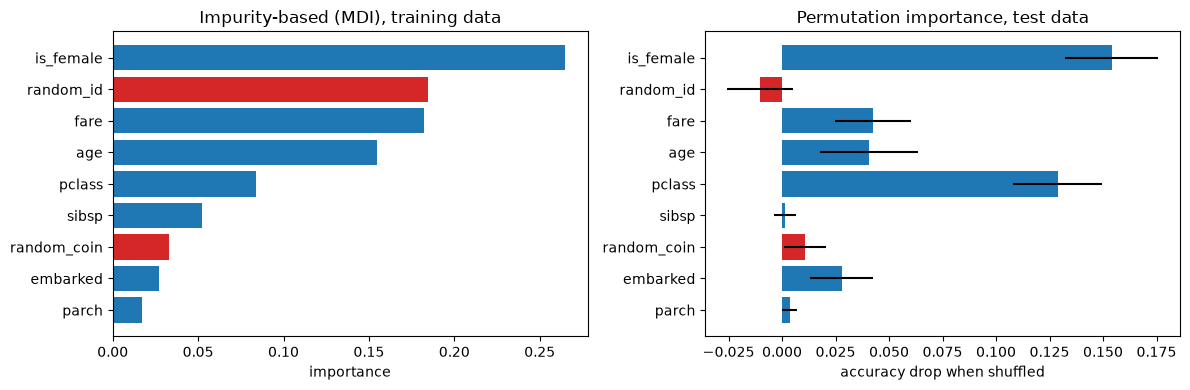

MDI rank of random_id: 2 of 9 (importance 0.185); random_coin: rank 7 (0.033)
permutation importance of random_id on test: -0.0104 ± 0.0155
after cost-complexity pruning, MDI of random_id drops to 0.000


In [28]:
noise_gen = np.random.default_rng(SEED)
X_noise = X_tit.assign(random_id=noise_gen.integers(0, 1000, len(X_tit)).astype(float),
                       random_coin=noise_gen.integers(0, 2, len(X_tit)).astype(float))
Xn_tr, Xn_te = X_noise.loc[X_t_tr.index], X_noise.loc[X_t_te.index]

deep = DecisionTreeClassifier(random_state=0).fit(Xn_tr, y_t_tr)
mdi = pd.Series(deep.feature_importances_, index=X_noise.columns)
perm = permutation_importance(deep, Xn_te, y_t_te, n_repeats=30, random_state=SEED)
perm_mean = pd.Series(perm.importances_mean, index=X_noise.columns)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
order_mdi = mdi.sort_values()
axes[0].barh(order_mdi.index, order_mdi.values, color=["#d62728" if c.startswith("random") else "#1f77b4" for c in order_mdi.index])
axes[0].set(title="Impurity-based (MDI), training data", xlabel="importance")
order_perm = perm_mean.loc[order_mdi.index]
axes[1].barh(order_perm.index, order_perm.values, xerr=pd.Series(perm.importances_std, index=X_noise.columns).loc[order_mdi.index],
             color=["#d62728" if c.startswith("random") else "#1f77b4" for c in order_perm.index])
axes[1].set(title="Permutation importance, test data", xlabel="accuracy drop when shuffled")
plt.tight_layout()
plt.show()

mdi_rank = mdi.rank(ascending=False).astype(int)
print(f"MDI rank of random_id: {mdi_rank['random_id']} of {len(mdi)} (importance {mdi['random_id']:.3f}); "
      f"random_coin: rank {mdi_rank['random_coin']} ({mdi['random_coin']:.3f})")
print(f"permutation importance of random_id on test: {perm_mean['random_id']:+.4f} ± {perm.importances_std[list(X_noise.columns).index('random_id')]:.4f}")
pruned_noise = DecisionTreeClassifier(random_state=0, ccp_alpha=best_row["alpha"]).fit(Xn_tr, y_t_tr)
print(f"after cost-complexity pruning, MDI of random_id drops to {pd.Series(pruned_noise.feature_importances_, index=X_noise.columns)['random_id']:.3f}")

### ✍️ Your Turn

Which **real** feature has the largest **permutation** importance on the test set? Store its name (a string) in `top_perm_feature`.

In [29]:
top_perm_feature = None  # TODO: your code here
check("top_perm_feature", top_perm_feature, perm_mean.drop(["random_id", "random_coin"]).idxmax(), hint="perm_mean is a pandas Series; drop the random columns, then idxmax().")

⏳ top_perm_feature: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
top_perm_feature = perm_mean.drop(["random_id", "random_coin"]).idxmax()
check("top_perm_feature", top_perm_feature, perm_mean.drop(["random_id", "random_coin"]).idxmax())
```
</details>

> 💡 **Interview angle:** "Why is impurity-based feature importance biased?" — it is measured on training data and sums gains from every split, so high-cardinality or continuous features (many candidate thresholds) collect importance from splits that only fit noise. Use permutation importance on held-out data (or SHAP), and beware correlated features, which share or hide importance under both methods.

## 11. Axis-Aligned Boundaries 🟡

Every split is "feature ≤ threshold", so a tree draws boundaries **parallel to the axes**. **Assumption:** the signal lines up with individual features. When the true boundary is **diagonal** (a combination of features), the tree needs a staircase of many splits. Real example: breast-cancer tumours by `worst area` and `worst smoothness` (standardized for the picture).

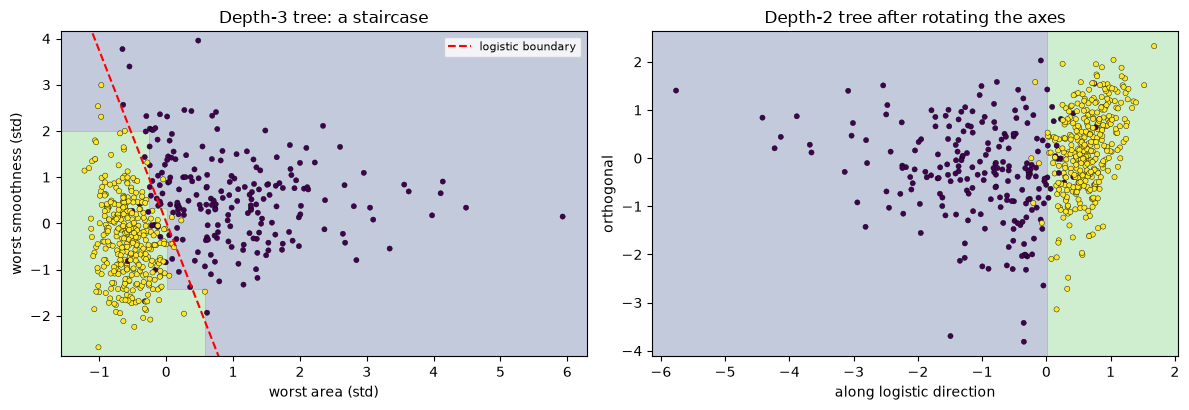

inputs               original features  rotated features
model                                                   
full tree leaves                43.000            34.000
logistic regression              0.958               NaN
tree depth 2                     0.902             0.961
tree depth 3                     0.938             0.954
tree depth 5                     0.935             0.944


In [30]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
diag_pair = ["worst area", "worst smoothness"]
X_diag = StandardScaler().fit_transform(cancer.data[:, [list(cancer.feature_names).index(f) for f in diag_pair]])
y_diag = cancer.target                                    # 0 = malignant, 1 = benign
cv_bc = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

logit_diag = LogisticRegression().fit(X_diag, y_diag)
w_dir = logit_diag.coef_.ravel() / np.linalg.norm(logit_diag.coef_)
X_rotated = np.column_stack([X_diag @ w_dir, X_diag @ np.array([-w_dir[1], w_dir[0]])])   # axis 1 = the diagonal direction

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
plot_tree_regions(DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_diag, y_diag), X_diag, y_diag, axes[0],
                  "Depth-3 tree: a staircase", names=[f + " (std)" for f in diag_pair])
xx_line = np.linspace(X_diag[:, 0].min(), X_diag[:, 0].max(), 50)
axes[0].plot(xx_line, -(logit_diag.intercept_[0] + logit_diag.coef_[0, 0] * xx_line) / logit_diag.coef_[0, 1], "r--", label="logistic boundary")
axes[0].set_ylim(X_diag[:, 1].min() - 0.2, X_diag[:, 1].max() + 0.2)
axes[0].legend(fontsize=8)
plot_tree_regions(DecisionTreeClassifier(max_depth=2, random_state=0).fit(X_rotated, y_diag), X_rotated, y_diag, axes[1],
                  "Depth-2 tree after rotating the axes", names=["along logistic direction", "orthogonal"])
plt.tight_layout()
plt.show()

axis_rows = []
for name, X_use in [("original features", X_diag), ("rotated features", X_rotated)]:
    for depth in [2, 3, 5]:
        s = cross_val_score(DecisionTreeClassifier(max_depth=depth, random_state=0), X_use, y_diag, cv=cv_bc)
        axis_rows.append({"inputs": name, "model": f"tree depth {depth}", "CV acc": s.mean()})
    axis_rows.append({"inputs": name, "model": "full tree leaves", "CV acc": DecisionTreeClassifier(random_state=0).fit(X_use, y_diag).get_n_leaves()})
axis_rows.append({"inputs": "original features", "model": "logistic regression", "CV acc": cross_val_score(LogisticRegression(), X_diag, y_diag, cv=cv_bc).mean()})
axis_df = pd.DataFrame(axis_rows)
print(axis_df.pivot(index="model", columns="inputs", values="CV acc").round(3).to_string())
# (the rotation uses a logistic fit on all rows — fine for this illustration, but in real work learn it inside CV)

**Fixes:** engineer combined features (ratios, differences, PCA directions), use oblique trees, or average many trees — a forest's many staircases smooth the boundary.

> 💡 **Interview angle:** "What kind of boundary can a decision tree represent easily?" — axis-aligned rectangles. A diagonal boundary like $x_1 + x_2 > c$ needs many splits; a linear model gets it with one weight vector. That's also why trees are invariant to monotone rescaling of a single feature but **not** to rotations of the feature space.

## 12. Instability: Trees on Bootstrap Samples Disagree 🔴

A **bootstrap sample** draws $n$ rows *with replacement* from the training set (~63% unique rows). If trees were stable, trees fitted on different bootstrap samples would look alike. They don't — a different early split changes everything below it. That high **variance** is exactly what random forests exploit.

 bootstrap              root left child split  leaves  test acc
         0 is_female <= 0.50     age <= 15.00     163     0.750
         1 is_female <= 0.50      age <= 9.50     152     0.729
         2 is_female <= 0.50     age <= 12.50     166     0.784
         3 is_female <= 0.50     age <= 13.00     160     0.713
         4 is_female <= 0.50    fare <= 26.27     153     0.750
         5 is_female <= 0.50     age <= 14.50     157     0.774
         6 is_female <= 0.50     age <= 12.50     163     0.710
         7 is_female <= 0.50   pclass <= 1.50     155     0.744

two bootstrap trees disagree on 21.8% of test passengers on average (first 20 trees)
single-tree test accuracy ranges 0.698 – 0.784 (mean 0.740)


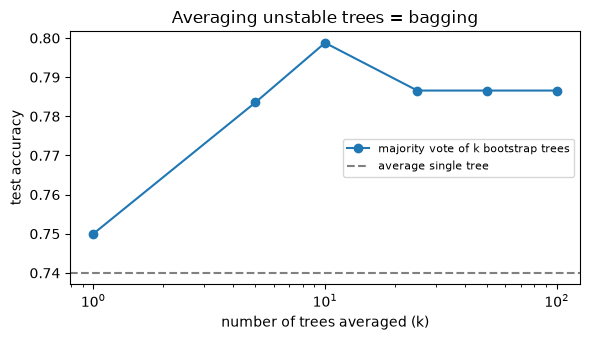

{1: 0.75, 5: 0.784, 10: 0.799, 25: 0.787, 50: 0.787, 100: 0.787}


In [31]:
n_boot = 100
boot_preds, boot_structure = [], []
for b in range(n_boot):
    idx = np.random.default_rng(b).integers(0, len(y_t_tr), len(y_t_tr))
    tree_b = DecisionTreeClassifier(random_state=0).fit(X_t_tr.iloc[idx], y_t_tr[idx])
    tb = tree_b.tree_
    boot_preds.append(tree_b.predict(X_t_te))
    if b < 8:
        boot_structure.append({"bootstrap": b, "root": f"{tit_features[tb.feature[0]]} <= {tb.threshold[0]:.2f}",
                               "left child split": f"{tit_features[tb.feature[1]]} <= {tb.threshold[1]:.2f}" if tb.children_left[1] != -1 else "leaf",
                               "leaves": tree_b.get_n_leaves(), "test acc": np.mean(boot_preds[-1] == y_t_te)})
boot_preds = np.array(boot_preds)
print(pd.DataFrame(boot_structure).round(3).to_string(index=False))

pairwise = np.mean([np.mean(boot_preds[i] != boot_preds[j]) for i in range(20) for j in range(i + 1, 20)])
single_accs = (boot_preds == y_t_te).mean(axis=1)
print(f"\ntwo bootstrap trees disagree on {pairwise:.1%} of test passengers on average (first 20 trees)")
print(f"single-tree test accuracy ranges {single_accs.min():.3f} – {single_accs.max():.3f} (mean {single_accs.mean():.3f})")

vote_sizes = [1, 5, 10, 25, 50, 100]
vote_acc = [np.mean((boot_preds[:k].mean(axis=0) > 0.5) == y_t_te) for k in vote_sizes]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(vote_sizes, vote_acc, "o-", label="majority vote of k bootstrap trees")
ax.axhline(single_accs.mean(), color="gray", ls="--", label="average single tree")
ax.set(xscale="log", xlabel="number of trees averaged (k)", ylabel="test accuracy", title="Averaging unstable trees = bagging")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print({k: round(float(a), 3) for k, a in zip(vote_sizes, vote_acc)})

> 💡 **Interview angle:** "Why do random forests beat a single tree?" — a deep tree has low bias but high variance: small data changes produce different trees (shown above). Averaging $B$ trees with pairwise correlation $\rho$ cuts the variance from $\sigma^2$ to $\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$; bagging reduces $\sigma^2/B$, and random feature subsets reduce $\rho$. Next notebook: [09 · Random Forest and Bagging](09_Random_Forest_and_Bagging.ipynb).

## 13. Head-to-Head on Real Data 🟡

Titanic training set, **same 5 folds**, every model with its preprocessing inside a pipeline (trees get NaNs natively; the others get median imputation and scaling):

In [32]:
impute_scale = lambda est: make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), est)
contenders = {
    "Tree (depth 3)": DecisionTreeClassifier(max_depth=3, random_state=0),
    f"Tree (ccp α={best_row['alpha']:.4f})": DecisionTreeClassifier(ccp_alpha=best_row["alpha"], random_state=0),
    "Tree (unpruned)": DecisionTreeClassifier(random_state=0),
    "LogisticRegression": impute_scale(LogisticRegression(max_iter=2000)),
    "KNN (k=15)": impute_scale(KNeighborsClassifier(n_neighbors=15)),
    "SVC rbf": impute_scale(SVC()),
}
h2h_rows = []
for name, est in contenders.items():
    res = cross_validate(est, X_t_tr, y_t_tr, cv=cv_t, scoring="accuracy")
    h2h_rows.append({"model": name, "CV acc": res["test_score"].mean(), "CV std": res["test_score"].std(),
                     "fit ms": res["fit_time"].mean() * 1000, "predict ms": res["score_time"].mean() * 1000})
h2h = pd.DataFrame(h2h_rows).sort_values("CV acc", ascending=False).round(4)
print(h2h.to_string(index=False))
leader = h2h.iloc[0]
close = h2h[h2h["CV acc"] >= leader["CV acc"] - leader["CV std"]]["model"].tolist()
print(f"\nleader: {leader['model']}; within one fold-std of it: {close}")
print(f"the unpruned tree trails the leader by {leader['CV acc'] - h2h.set_index('model').loc['Tree (unpruned)', 'CV acc']:.3f} — pruning is not optional")

              model  CV acc  CV std  fit ms  predict ms
            SVC rbf  0.8084  0.0276  5.0994      2.4257
     Tree (depth 3)  0.8033  0.0259  0.7082      0.3830
         KNN (k=15)  0.7900  0.0251  1.2170      1.4590
Tree (ccp α=0.0088)  0.7870  0.0286  1.0718      0.3559
 LogisticRegression  0.7819  0.0192  1.6534      0.5586
    Tree (unpruned)  0.7330  0.0322  1.0470      0.3736

leader: SVC rbf; within one fold-std of it: ['SVC rbf', 'Tree (depth 3)', 'KNN (k=15)', 'Tree (ccp α=0.0088)', 'LogisticRegression']
the unpruned tree trails the leader by 0.075 — pruning is not optional


## 🔧 Build It From Scratch

[ML Fundamentals](01_ML_Fundamentals_From_Scratch.ipynb) built a depth-limited Gini classifier and matched scikit-learn's class counts. Here we go further: one NumPy **CART** class that does **classification (Gini)** and **regression (squared error)**, supports `max_depth` and `min_samples_leaf`, and follows scikit-learn's exact rules:

| Rule (read from scikit-learn's `_splitter.pyx` / `_tree.pyx`) | In our code |
|---|---|
| features are compared as **float32**; threshold = midpoint `x[i]/2 + x[i+1]/2` in float64 | `X.astype(np.float32)` and the same midpoint formula |
| never cut between values closer than `1e-7`; skip constant features | `FEATURE_THRESHOLD = 1e-7` |
| reject splits leaving a child with fewer than `min_samples_leaf` rows | a mask on candidate positions |
| a node is a leaf if depth ≥ `max_depth`, $n < 2$·`min_samples_leaf`, $n<$ `min_samples_split`, or impurity ≤ machine epsilon | same checks |
| a split replaces the current best only if **strictly** better | `if score > best` |
| Gini proxy: $-(n_L\,G_L + n_R\,G_R)$; MSE proxy: $S_L^2/n_L + S_R^2/n_R$ (larger is better) | vectorized over all thresholds with cumulative sums |

**Ties, honestly.** scikit-learn visits features in a **random order** (seeded by `random_state`) and keeps the first best split; we scan features left to right. When two splits are *exactly* equally good on the training rows, the trees can legitimately differ. Our checker therefore walks both trees together and, wherever the chosen splits differ, **proves the two splits have identical quality**; predictions must match on every test row that doesn't pass through such a tie.

In [33]:
FEATURE_THRESHOLD = 1e-7


class CART:
    """Minimal CART: task='classification' (Gini) or 'regression' (squared error)."""

    def __init__(self, task="classification", max_depth=None, min_samples_leaf=1, min_samples_split=2):
        self.task, self.max_depth = task, max_depth
        self.min_samples_leaf, self.min_samples_split = min_samples_leaf, min_samples_split

    def fit(self, X, y):
        self.X_ = np.asarray(X, dtype=np.float32)
        if self.task == "classification":
            self.classes_, self.y_ = np.unique(y, return_inverse=True)
        else:
            self.y_ = np.asarray(y, dtype=float)
        self.root_ = self._grow(np.arange(len(self.y_)), depth=0)
        return self

    # --- impurity and split scoring -------------------------------------------------
    def _node_impurity(self, rows):
        if self.task == "classification":
            return gini_from_counts(np.bincount(self.y_[rows], minlength=len(self.classes_)))
        return self.y_[rows].var()

    def _scores_along_sorted(self, y_sorted):
        """Proxy score for every cut position p (left = first p rows); larger is better."""
        n = len(y_sorted)
        n_left = np.arange(1, n)
        if self.task == "classification":
            onehot = np.eye(len(self.classes_))[y_sorted]
            left = np.cumsum(onehot, axis=0)[:-1]
            right = onehot.sum(axis=0) - left
            return -(n_left * gini_from_counts(left) + (n - n_left) * gini_from_counts(right))
        csum = np.cumsum(y_sorted)[:-1]
        total = y_sorted.sum()
        return csum ** 2 / n_left + (total - csum) ** 2 / (n - n_left)

    def split_score(self, rows, feature, threshold):
        """Proxy score of one given split (used to verify ties against scikit-learn)."""
        go_left = self.X_[rows, feature] <= threshold
        order = np.r_[rows[go_left], rows[~go_left]]
        return self._scores_along_sorted(self.y_[order])[go_left.sum() - 1]

    def _best_split(self, rows):
        best_score, best_feature, best_threshold = -np.inf, None, None
        n, m = len(rows), self.min_samples_leaf
        for f in range(self.X_.shape[1]):
            order = np.argsort(self.X_[rows, f], kind="stable")
            xs = self.X_[rows[order], f]
            if xs[-1] <= xs[0] + FEATURE_THRESHOLD:                       # constant feature in this node
                continue
            scores = self._scores_along_sorted(self.y_[rows[order]])
            p = np.arange(1, n)
            allowed = (p >= m) & (n - p >= m) & (xs[1:] > xs[:-1] + FEATURE_THRESHOLD)
            if not allowed.any():
                continue
            scores = np.where(allowed, scores, -np.inf)
            k = int(np.argmax(scores))                                    # first best threshold within the feature
            if scores[k] > best_score:                                    # strictly better than earlier features
                best_score, best_feature = scores[k], f
                best_threshold = np.float64(xs[k]) / 2.0 + np.float64(xs[k + 1]) / 2.0
        return best_score, best_feature, best_threshold

    # --- growing and predicting -----------------------------------------------------
    def _grow(self, rows, depth):
        n = len(rows)
        if self.task == "classification":
            node = {"rows": rows, "value": np.bincount(self.y_[rows], minlength=len(self.classes_))}
        else:
            node = {"rows": rows, "value": self.y_[rows].mean()}
        is_leaf = ((self.max_depth is not None and depth >= self.max_depth) or n < self.min_samples_split
                   or n < 2 * self.min_samples_leaf or self._node_impurity(rows) <= np.finfo(float).eps)
        if is_leaf:
            return node
        score, feature, threshold = self._best_split(rows)
        if feature is None:                                              # no valid split exists
            return node
        go_left = self.X_[rows, feature] <= threshold
        node.update(feature=feature, threshold=threshold, score=score,
                    left=self._grow(rows[go_left], depth + 1), right=self._grow(rows[~go_left], depth + 1))
        return node

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)
        out = []
        for x in X:
            node = self.root_
            while "feature" in node:
                node = node["left"] if x[node["feature"]] <= node["threshold"] else node["right"]
            out.append(self.classes_[node["value"].argmax()] if self.task == "classification" else node["value"])
        return np.array(out)


def compare_with_sklearn(ours, sk, X_train, X_test):
    """Walk both trees together. Returns (nodes compared, tie nodes, sklearn ids of tie nodes)."""
    t_sk = sk.tree_
    X_train32 = np.asarray(X_train, dtype=np.float32)
    paths = sk.decision_path(X_train32).tocsc()
    stack, compared, tie_nodes = [(ours.root_, 0)], 0, []
    while stack:
        node, i = stack.pop()
        compared += 1
        sk_rows = paths[:, i].indices
        assert np.array_equal(np.sort(node["rows"]), np.sort(sk_rows)), f"sklearn node {i}: different training rows"
        sk_leaf = t_sk.children_left[i] == -1
        assert ("feature" not in node) == sk_leaf, f"sklearn node {i}: leaf status differs"
        if sk_leaf:
            continue
        same_split = node["feature"] == t_sk.feature[i] and np.isclose(node["threshold"], t_sk.threshold[i], rtol=0, atol=1e-9)
        if not same_split:
            sk_score = ours.split_score(node["rows"], t_sk.feature[i], t_sk.threshold[i])
            assert np.isclose(sk_score, node["score"], rtol=1e-9, atol=1e-9), f"node {i}: sklearn's split is not an exact tie"
            tie_nodes.append(i)
            continue                                                      # subtrees below a tie may legitimately differ
        stack += [(node["right"], t_sk.children_right[i]), (node["left"], t_sk.children_left[i])]
    return compared, tie_nodes

**Classifier on the penguins** (4 features, 3 species) for several settings, and **regressor on California housing** (a 4,000-district sample, 8 features):

In [34]:
def run_match(task, X_tr_, y_tr_, X_te_, settings):
    rows_out = []
    for max_depth, min_leaf in settings:
        start = time.perf_counter()
        ours = CART(task, max_depth=max_depth, min_samples_leaf=min_leaf).fit(X_tr_, y_tr_)
        ours_s = time.perf_counter() - start
        Est = DecisionTreeClassifier if task == "classification" else DecisionTreeRegressor
        sk = Est(max_depth=max_depth, min_samples_leaf=min_leaf, random_state=0).fit(X_tr_, y_tr_)
        compared, ties = compare_with_sklearn(ours, sk, X_tr_, X_te_)
        pred_ours, pred_sk = ours.predict(X_te_), sk.predict(np.asarray(X_te_, dtype=np.float32))
        through_tie = np.asarray(sk.decision_path(np.asarray(X_te_, dtype=np.float32))[:, ties].sum(axis=1)).ravel() > 0 if ties else np.zeros(len(X_te_), bool)
        same = (pred_ours == pred_sk) if task == "classification" else np.isclose(pred_ours, pred_sk, rtol=1e-12, atol=1e-12)
        assert same[~through_tie].all(), "a prediction differs on a row that never meets a tie"
        rows_out.append({"max_depth": "None" if max_depth is None else max_depth, "min_samples_leaf": min_leaf, "nodes (sklearn)": sk.tree_.node_count,
                         "nodes matched": compared, "exact ties": len(ties), "test rows via a tie": int(through_tie.sum()),
                         "test predictions identical": f"{same.mean():.1%}", "ours s": round(ours_s, 3)})
    return pd.DataFrame(rows_out)


print("CART classifier (Gini) vs DecisionTreeClassifier — penguins")
print(run_match("classification", X_pg_tr, y_pg_tr, X_pg_te, [(3, 1), (4, 3), (None, 5), (None, 1)]).to_string(index=False))

cal_idx = np.random.default_rng(0).choice(len(y_h), 4000, replace=False)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_h[cal_idx], y_h[cal_idx], test_size=0.25, random_state=SEED)
print("\nCART regressor (squared error) vs DecisionTreeRegressor — California housing")
print(run_match("regression", Xc_tr, yc_tr, Xc_te, [(4, 1), (6, 10), (None, 20)]).to_string(index=False))
print("\n✅ every compared node has the same training rows as scikit-learn; every differing split is an exact tie; "
      "all predictions not routed through a tie are identical")

CART classifier (Gini) vs DecisionTreeClassifier — penguins
max_depth  min_samples_leaf  nodes (sklearn)  nodes matched  exact ties  test rows via a tie test predictions identical  ours s
        3                 1               13             11           1                    0                     100.0%   0.001
        4                 3               19             17           1                    3                      99.0%   0.001
     None                 5               13             13           0                    0                     100.0%   0.001
     None                 1               23             17           3                    3                      99.0%   0.001

CART regressor (squared error) vs DecisionTreeRegressor — California housing


max_depth  min_samples_leaf  nodes (sklearn)  nodes matched  exact ties  test rows via a tie test predictions identical  ours s
        4                 1               31             31           0                    0                     100.0%   0.005
        6                10              105            105           0                    0                     100.0%   0.009
     None                20              229            229           0                    0                     100.0%   0.017

✅ every compared node has the same training rows as scikit-learn; every differing split is an exact tie; all predictions not routed through a tie are identical


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — A too-good root split means leakage
Titanic's `boat` column (lifeboat number) is only known **after** the sinking. A tree finds it instantly.

In [35]:
X_leak = X_tit.assign(has_boat=titanic["boat"].notna().astype(float))
leaky = cross_val_score(DecisionTreeClassifier(max_depth=3, random_state=0), X_leak.loc[X_t_tr.index], y_t_tr, cv=cv_t).mean()
leaky_root = list(X_leak.columns)[DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_leak.loc[X_t_tr.index], y_t_tr).tree_.feature[0]]
honest = cross_val_score(DecisionTreeClassifier(max_depth=3, random_state=0), X_t_tr, y_t_tr, cv=cv_t).mean()
print(f"❌ with has_boat: CV accuracy {leaky:.3f}, root split on '{leaky_root}'")
print(f"✅ without it   : CV accuracy {honest:.3f} — ask 'would I know this feature at prediction time?'")

❌ with has_boat: CV accuracy 0.979, root split on 'has_boat'
✅ without it   : CV accuracy 0.803 — ask 'would I know this feature at prediction time?'


### ❌ Pitfall 2 — Expecting a regression tree to extrapolate
Train only on districts with median income below 6 (tens of $k), then predict richer districts.

In [36]:
from sklearn.linear_model import LinearRegression

low_income = X_h_tr[:, medinc] < 6
x_low, y_low = X_h_tr[low_income][:, [medinc]], y_h_tr[low_income]
queries = np.array([[5.0], [7.0], [10.0], [15.0]])
tree_extrap = DecisionTreeRegressor(max_depth=6, random_state=0).fit(x_low, y_low).predict(queries)
linear_extrap = LinearRegression().fit(x_low, y_low).predict(queries)
print("median income :", queries.ravel())
print("❌ tree        :", tree_extrap.round(3), "← flat beyond the training range")
print("✅ linear model:", linear_extrap.round(3), "← continues the trend (use linear models, or linear-leaf boosting, when you must extrapolate)")

median income : [ 5.  7. 10. 15.]
❌ tree        : [2.313 2.695 2.695 2.695] ← flat beyond the training range
✅ linear model: [2.519 3.351 4.598 6.677] ← continues the trend (use linear models, or linear-leaf boosting, when you must extrapolate)


### ❌ Pitfall 3 — Re-encoding categories on each new batch
`pd.factorize` numbers categories in order of appearance, so the same category gets a different code in a batch that doesn't contain every category.

In [37]:
sex_train = titanic.loc[X_t_tr.index, "sex"].astype(object)
codes_tr, uniques_tr = pd.factorize(sex_train)                      # codes in order of first appearance
X_fact_tr = X_t_tr.drop(columns="is_female").assign(sex_code=codes_tr.astype(float))
fact_tree = DecisionTreeClassifier(max_depth=4, random_state=0).fit(X_fact_tr, y_t_tr)

batch_sex = uniques_tr[1]                                            # a batch with only the category that was coded 1 in training
test_sex = titanic.loc[X_t_te.index, "sex"].astype(object)
batch_mask = (test_sex == batch_sex).to_numpy()
codes_batch, uniques_batch = pd.factorize(test_sex[batch_mask])     # ❌ re-encoded per batch → becomes 0
right_codes = pd.Index(uniques_tr).get_indexer(test_sex[batch_mask])  # ✅ the training mapping
X_batch = X_t_te[batch_mask].drop(columns="is_female")
wrong_pred = fact_tree.predict(X_batch.assign(sex_code=codes_batch.astype(float)))
right_pred = fact_tree.predict(X_batch.assign(sex_code=right_codes.astype(float)))
print("❌ training codes:", {c: i for i, c in enumerate(uniques_tr)}, f"| a batch of {batch_mask.sum()} '{batch_sex}' passengers re-encoded:",
      {c: i for i, c in enumerate(uniques_batch)})
print(f"   → predictions silently changed for {np.mean(wrong_pred != right_pred):.0%} of the batch; "
      f"batch accuracy {np.mean(wrong_pred == y_t_te[batch_mask]):.3f} instead of {np.mean(right_pred == y_t_te[batch_mask]):.3f}")
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1).fit(titanic.loc[X_t_tr.index, ["sex"]])
print("✅ one OrdinalEncoder fitted on train:", dict(zip(enc.categories_[0], range(len(enc.categories_[0])))), "— reused for every batch inside a Pipeline")

❌ training codes: {'female': 0, 'male': 1} | a batch of 207 'male' passengers re-encoded: {'male': 0}
   → predictions silently changed for 90% of the batch; batch accuracy 0.217 instead of 0.841
✅ one OrdinalEncoder fitted on train: {'female': 0, 'male': 1} — reused for every batch inside a Pipeline


### ❌ Pitfall 4 — Trusting probabilities from tiny leaves
A fully grown tree's leaves are mostly pure, so `predict_proba` says 0% or 100% — and log loss punishes confident mistakes brutally.

In [38]:
for label, est in [("❌ unpruned tree        ", DecisionTreeClassifier(random_state=0)),
                   ("✅ min_samples_leaf=20  ", DecisionTreeClassifier(min_samples_leaf=20, random_state=0))]:
    proba = est.fit(X_t_tr, y_t_tr).predict_proba(X_t_te)[:, 1]
    extreme = np.mean((proba == 0) | (proba == 1))
    clipped = np.clip(proba, 1e-15, 1 - 1e-15)
    ll = -np.mean(y_t_te * np.log(clipped) + (1 - y_t_te) * np.log(1 - clipped))
    print(f"{label}: {extreme:.0%} of test probabilities are exactly 0 or 1 | test log loss {ll:.3f} | ROC-AUC {roc_auc_score(y_t_te, proba):.3f}")

❌ unpruned tree        : 94% of test probabilities are exactly 0 or 1 | test log loss 7.513 | ROC-AUC 0.760
✅ min_samples_leaf=20  : 15% of test probabilities are exactly 0 or 1 | test log loss 0.595 | ROC-AUC 0.872


### ❌ Pitfall 5 — Irreproducible trees without `random_state`
Features are visited in random order, so exact ties are broken differently on each fit. Same data, same settings, different trees:

In [39]:
structures = set()
for seed in range(10):
    t_seed = DecisionTreeClassifier(random_state=seed).fit(X_t_tr, y_t_tr).tree_
    structures.add((tuple(t_seed.feature), tuple(np.round(t_seed.threshold, 6))))
print(f"❌ 10 fits with different random_state values → {len(structures)} different tree structure(s)")
t_a = DecisionTreeClassifier(random_state=0).fit(X_t_tr, y_t_tr).tree_
t_b = DecisionTreeClassifier(random_state=0).fit(X_t_tr, y_t_tr).tree_
print(f"✅ fixed random_state=0 twice → identical: {np.array_equal(t_a.feature, t_b.feature) and np.array_equal(t_a.threshold, t_b.threshold)}")

❌ 10 fits with different random_state values → 10 different tree structure(s)
✅ fixed random_state=0 twice → identical: True


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Gini of a three-class node
A node holds 10 Adelie, 30 Gentoo, 0 Chinstrap penguins. Store its Gini impurity in `gini_node`.

In [40]:
gini_node = None  # TODO
check("gini_node", gini_node, 0.375, hint="p = [0.25, 0.75, 0]; Gini = 1 − Σ p².")

⏳ gini_node: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
p_node = np.array([10, 30, 0]) / 40
gini_node = 1 - np.sum(p_node ** 2)
check("gini_node", gini_node, 0.375)
```
</details>

### 🟢 Exercise 2 — Gini gain of a split
Parent `[40, 40]` is split into `[30, 10]` and `[10, 30]`. Store the **Gini gain** (parent Gini − weighted child Gini) in `gini_gain_a`.

In [41]:
gini_gain_a = None  # TODO
check("gini_gain_a", gini_gain_a, 0.125, hint="Parent Gini 0.5; each child has Gini 1 − (0.75² + 0.25²) = 0.375 and weight 0.5.")

⏳ gini_gain_a: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
child = 1 - (0.75 ** 2 + 0.25 ** 2)                 # 0.375
gini_gain_a = 0.5 - (0.5 * child + 0.5 * child)
check("gini_gain_a", gini_gain_a, 0.125)
```
</details>

### 🟢 Exercise 3 — The best constant in a leaf
A regression leaf holds targets `[1, 2, 3, 10]`. Store `[best constant under squared error, best constant under absolute error]` in `leaf_constants`.

In [42]:
leaf_targets = np.array([1.0, 2.0, 3.0, 10.0])
leaf_constants = None  # TODO
check("leaf_constants", leaf_constants, [4.0, 2.5], hint="Squared error → mean; absolute error → median.")

⏳ leaf_constants: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
leaf_targets = np.array([1.0, 2.0, 3.0, 10.0])
leaf_constants = [leaf_targets.mean(), np.median(leaf_targets)]
check("leaf_constants", leaf_constants, [4.0, 2.5])
```
The outlier 10 drags the mean to 4 but barely moves the median — why `absolute_error` suits heavy-tailed targets.
</details>

### 🟡 Exercise 4 — Best threshold by scanning
For the feature `x_ex` and labels `y_ex`, find the Gini-best threshold (midpoint between consecutive sorted distinct values; if several tie, take the **smallest**). Store it in `best_thr`.

In [43]:
x_ex = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])
y_ex = np.array([0, 0, 1, 0, 1, 1, 1, 0])
best_thr = None  # TODO
check("best_thr", best_thr, DecisionTreeClassifier(max_depth=1).fit(x_ex.reshape(-1, 1), y_ex).tree_.threshold[0],
      hint="Loop over the 7 midpoints, compute (n_L·Gini_L + n_R·Gini_R)/n for each, keep the argmin.")

⏳ best_thr: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
x_ex = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])
y_ex = np.array([0, 0, 1, 0, 1, 1, 1, 0])
order_ex = np.argsort(x_ex)
xs_ex, ys_ex = x_ex[order_ex], y_ex[order_ex]
best_thr, best_imp = None, np.inf
for k in range(len(xs_ex) - 1):
    left, right = ys_ex[:k + 1], ys_ex[k + 1:]
    imp = (len(left) * gini_from_counts(np.bincount(left, minlength=2)) + len(right) * gini_from_counts(np.bincount(right, minlength=2))) / len(ys_ex)
    if imp < best_imp:                                # strict < keeps the smallest threshold among ties
        best_thr, best_imp = (xs_ex[k] + xs_ex[k + 1]) / 2, imp
check("best_thr", best_thr, DecisionTreeClassifier(max_depth=1).fit(x_ex.reshape(-1, 1), y_ex).tree_.threshold[0])
```
</details>

### 🟡 Exercise 5 — Weakest link
An internal node has $R(t) = 0.10$ if collapsed to a leaf; its subtree has 4 leaves with total $R(T_t) = 0.04$. Compute its effective alpha $g(t)$, and whether it is pruned when `ccp_alpha = 0.015` (pruned if $g(t) \le$ alpha). Store `[g, 1 if pruned else 0]` in `weakest_link`.

In [44]:
weakest_link = None  # TODO
check("weakest_link", weakest_link, [0.02, 0], hint="g = (R(t) − R(T_t)) / (leaves − 1).")

⏳ weakest_link: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
g_t = (0.10 - 0.04) / (4 - 1)                       # 0.02
weakest_link = [g_t, 1 if g_t <= 0.015 else 0]      # 0.02 > 0.015 → kept
check("weakest_link", weakest_link, [0.02, 0])
```
The subtree removes 0.06 of impurity with 3 extra leaves — worth it at a price of 0.015 per leaf, not at 0.03.
</details>

### 🔴 Exercise 6 — Predict from the raw tree arrays (interview-style)
Without calling `predict`, compute `reg_sq`'s predictions for `X_h_te[:500]` using only `reg_sq.tree_.children_left`, `children_right`, `feature`, `threshold`, and `value`. Move **all rows at once** (one loop over depth, not over rows). Store the result in `array_preds`.

In [45]:
array_preds = None  # TODO
check("array_preds", array_preds, reg_sq.predict(X_h_te[:500]),
      hint="Cast X to float32 (sklearn does). node = zeros(n, int); while any node is internal: go left where x[feature[node]] <= threshold[node].")

⏳ array_preds: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
tr_ = reg_sq.tree_
X32 = X_h_te[:500].astype(np.float32)               # sklearn compares float32 features with float64 thresholds
node = np.zeros(len(X32), dtype=int)
rows_idx = np.arange(len(X32))
while True:
    internal = tr_.children_left[node] != -1
    if not internal.any():
        break
    go_left = X32[rows_idx, tr_.feature[node]] <= tr_.threshold[node]
    node = np.where(internal, np.where(go_left, tr_.children_left[node], tr_.children_right[node]), node)
array_preds = tr_.value[node][:, 0, 0]
check("array_preds", array_preds, reg_sq.predict(X_h_te[:500]))
```
For leaves `feature` is −2, so the comparison runs on garbage for finished rows — the outer `np.where(internal, …)` keeps them in place. (Real inputs with NaN would also need `missing_go_to_left`.)
</details>

## 🚀 Mini Project: Readable Diabetes Risk Rules

**Goal:** a clinic wants a **short list of if-then rules** to flag patients for follow-up diabetes care, using the real **Pima Indians Diabetes** data (768 women; plasma glucose, BMI, age, …; target: diabetes within five years). Build an interpretable, pruned tree, quantify the **depth/accuracy trade-off**, extract the rules, and evaluate **once** on a held-out test set — including what interpretability costs compared with logistic regression.

**Steps:** clean impossible zeros → split → depth trade-off → prune with CV → choose by a pre-registered rule → extract rules → one test evaluation.

### Step 1 — Load, mark impossible zeros as missing, split

In [46]:
pima = fetch_openml("diabetes", version=1, as_frame=True, data_home=DATA_HOME)
X_pima = pima.data.copy()
y_pima = (pima.target == "tested_positive").astype(int).to_numpy()
impossible_zero = ["plas", "pres", "skin", "insu", "mass"]        # glucose, blood pressure, skinfold, insulin, BMI can't be 0
print("zeros before cleaning:", {c: int((X_pima[c] == 0).sum()) for c in impossible_zero})
for col in impossible_zero:
    X_pima[col] = X_pima[col].mask(X_pima[col] == 0)              # → NaN; the tree handles it natively
print(f"{len(X_pima)} patients | diabetes rate {y_pima.mean():.3f} | columns: {list(X_pima.columns)}")

X_pm_tr, X_pm_te, y_pm_tr, y_pm_te = train_test_split(X_pima, y_pima, test_size=0.25, stratify=y_pima, random_state=SEED)
cv_pm = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"train {len(y_pm_tr)} | test {len(y_pm_te)} (locked until Step 5)")

zeros before cleaning: {'plas': 5, 'pres': 35, 'skin': 227, 'insu': 374, 'mass': 11}
768 patients | diabetes rate 0.349 | columns: ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']
train 576 | test 192 (locked until Step 5)


### Step 2 — The depth / accuracy trade-off (CV on training data only)

We score with **ROC-AUC** (ranking patients by risk) and keep `min_samples_leaf=10` so no rule rests on a handful of patients.

max_depth  leaves  CV AUC  CV std
        1       2   0.669   0.049
        2       4   0.727   0.054
        3       8   0.764   0.052
        4      13   0.771   0.052
        5      20   0.771   0.040
        6      28   0.774   0.045
     None      35   0.764   0.034


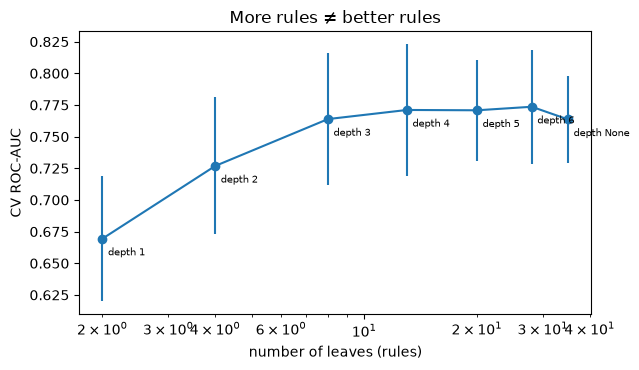

In [47]:
depth_rows = []
for depth in [1, 2, 3, 4, 5, 6, None]:
    est = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=10, random_state=0)
    s = cross_val_score(est, X_pm_tr, y_pm_tr, cv=cv_pm, scoring="roc_auc")
    depth_rows.append({"max_depth": "None" if depth is None else depth, "leaves": est.fit(X_pm_tr, y_pm_tr).get_n_leaves(),
                       "CV AUC": s.mean(), "CV std": s.std()})
depth_df = pd.DataFrame(depth_rows)
print(depth_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.errorbar(depth_df["leaves"], depth_df["CV AUC"], yerr=depth_df["CV std"], fmt="o-")
for _, row in depth_df.iterrows():
    ax.annotate(f"depth {row['max_depth']}", (row["leaves"], row["CV AUC"]), textcoords="offset points", xytext=(4, -12), fontsize=7)
ax.set(xscale="log", xlabel="number of leaves (rules)", ylabel="CV ROC-AUC", title="More rules ≠ better rules")
plt.tight_layout()
plt.show()

### Step 3 — Cost-complexity pruning path, chosen by CV

In [48]:
pm_path = DecisionTreeClassifier(min_samples_leaf=10, random_state=0).cost_complexity_pruning_path(X_pm_tr, y_pm_tr)
ccp_rows = []
for a in pm_path.ccp_alphas[:-1]:
    est = DecisionTreeClassifier(min_samples_leaf=10, ccp_alpha=a, random_state=0)
    s = cross_val_score(est, X_pm_tr, y_pm_tr, cv=cv_pm, scoring="roc_auc")
    ccp_rows.append({"ccp_alpha": a, "leaves": est.fit(X_pm_tr, y_pm_tr).get_n_leaves(), "CV AUC": s.mean(), "CV std": s.std()})
ccp_df = pd.DataFrame(ccp_rows)
print(ccp_df.round(4).to_string(index=False))

 ccp_alpha  leaves  CV AUC  CV std
    0.0000      35  0.7636  0.0343
    0.0002      34  0.7636  0.0343
    0.0003      33  0.7648  0.0356
    0.0004      31  0.7682  0.0317
    0.0007      30  0.7684  0.0314
    0.0007      29  0.7684  0.0314
    0.0009      28  0.7720  0.0269
    0.0013      27  0.7776  0.0275
    0.0013      26  0.7776  0.0275
    0.0016      25  0.7782  0.0268
    0.0016      23  0.7781  0.0267
    0.0023      21  0.7790  0.0290
    0.0025      19  0.7776  0.0282
    0.0028      18  0.7747  0.0377
    0.0031      17  0.7755  0.0384
    0.0039      14  0.7677  0.0302
    0.0040      11  0.7669  0.0310
    0.0049       9  0.7683  0.0382
    0.0054       8  0.7736  0.0348
    0.0059       7  0.7739  0.0325
    0.0102       6  0.7691  0.0360
    0.0105       5  0.7691  0.0360
    0.0147       4  0.7403  0.0511
    0.0180       3  0.7236  0.0492
    0.0194       2  0.7236  0.0492


### Step 4 — Choose with a rule written before looking at the test set, then extract the rules

**Rule (1-standard-error):** find the best CV AUC among all candidates (depth-limited and pruned); pick the candidate with the **fewest leaves** whose CV AUC is within one standard error ($\text{std}/\sqrt{5}$) of the best.

In [49]:
candidates = pd.concat([
    depth_df.assign(kind="max_depth", setting=depth_df["max_depth"].astype(str), value=list(depth_df["max_depth"])),
    ccp_df.assign(kind="ccp_alpha", setting=ccp_df["ccp_alpha"].map(lambda a: f"{a:.5f}"), value=list(ccp_df["ccp_alpha"])),
], ignore_index=True)[["kind", "setting", "value", "leaves", "CV AUC", "CV std"]]
best_cand = candidates.loc[candidates["CV AUC"].idxmax()]
threshold_1se = best_cand["CV AUC"] - best_cand["CV std"] / np.sqrt(cv_pm.get_n_splits())
eligible = candidates[candidates["CV AUC"] >= threshold_1se].sort_values(["leaves", "CV AUC"], ascending=[True, False])
chosen = eligible.iloc[0]
print(f"best CV AUC {best_cand['CV AUC']:.3f} ({best_cand['kind']}={best_cand['setting']}, {best_cand['leaves']} leaves); 1-SE threshold {threshold_1se:.3f}")
print(f"📌 chosen: {chosen['kind']}={chosen['setting']} → {chosen['leaves']} leaves, CV AUC {chosen['CV AUC']:.3f}")

if chosen["kind"] == "max_depth":
    rules_tree = DecisionTreeClassifier(max_depth=None if chosen["value"] == "None" else int(chosen["value"]), min_samples_leaf=10, random_state=0)
else:
    rules_tree = DecisionTreeClassifier(ccp_alpha=float(chosen["value"]), min_samples_leaf=10, random_state=0)   # exact alpha, not the rounded label
rules_tree.fit(X_pm_tr, y_pm_tr)
assert rules_tree.get_n_leaves() == chosen["leaves"], "refit tree should match the chosen candidate"
print()
print(export_text(rules_tree, feature_names=list(X_pima.columns), show_weights=True, decimals=1))

best CV AUC 0.779 (ccp_alpha=0.00229, 21 leaves); 1-SE threshold 0.766
📌 chosen: ccp_alpha=0.01048 → 5 leaves, CV AUC 0.769

|--- plas <= 132.5
|   |--- age <= 30.5
|   |   |--- weights: [213.0, 26.0] class: 0
|   |--- age >  30.5
|   |   |--- mass <= 26.9
|   |   |   |--- weights: [29.0, 0.0] class: 0
|   |   |--- mass >  26.9
|   |   |   |--- weights: [72.0, 53.0] class: 0
|--- plas >  132.5
|   |--- plas <= 154.5
|   |   |--- weights: [46.0, 44.0] class: 0
|   |--- plas >  154.5
|   |   |--- weights: [15.0, 78.0] class: 1



In [50]:
def leaf_rules(model, names):
    """One row per leaf: the full rule, how many training patients it covers, and their diabetes rate."""
    t_ = model.tree_
    out = []

    def walk(node, conditions):
        if t_.children_left[node] == -1:
            proportions = t_.value[node][0]
            out.append({"rule": " AND ".join(conditions) or "(all patients)", "patients": int(t_.n_node_samples[node]),
                        "diabetes rate": proportions[1]})
            return
        name, thr = names[t_.feature[node]], t_.threshold[node]
        missing_left = bool(t_.missing_go_to_left[node])
        walk(t_.children_left[node], conditions + [f"{name} <= {thr:.1f}" + (" (or missing)" if missing_left else "")])
        walk(t_.children_right[node], conditions + [f"{name} > {thr:.1f}" + ("" if missing_left else " (or missing)")])

    walk(0, [])
    return pd.DataFrame(out).sort_values("diabetes rate", ascending=False).reset_index(drop=True)


rules_table = leaf_rules(rules_tree, list(X_pima.columns))
with pd.option_context("display.max_colwidth", 120):
    print(rules_table.round(3).to_string())

                                                        rule  patients  diabetes rate
0                 plas > 132.5 (or missing) AND plas > 154.5        93          0.839
1   plas > 132.5 (or missing) AND plas <= 154.5 (or missing)        90          0.489
2  plas <= 132.5 AND age > 30.5 AND mass > 26.9 (or missing)       125          0.424
3                 plas <= 132.5 AND age <= 30.5 (or missing)       239          0.109
4              plas <= 132.5 AND age > 30.5 AND mass <= 26.9        29          0.000


### Step 5 — One evaluation on the locked test set

In [51]:
unpruned_pm = DecisionTreeClassifier(random_state=0).fit(X_pm_tr, y_pm_tr)
logit_pm = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LogisticRegression(max_iter=2000)).fit(X_pm_tr, y_pm_tr)

final_rows = []
for name, model in [(f"chosen tree ({rules_tree.get_n_leaves()} rules)", rules_tree), (f"unpruned tree ({unpruned_pm.get_n_leaves()} leaves)", unpruned_pm),
                    ("logistic regression (8 weights)", logit_pm)]:
    proba = model.predict_proba(X_pm_te)[:, 1]
    flag = proba >= 0.5
    final_rows.append({"model": name, "test AUC": roc_auc_score(y_pm_te, proba), "accuracy@0.5": accuracy_score(y_pm_te, flag),
                       "recall@0.5": recall_score(y_pm_te, flag), "precision@0.5": precision_score(y_pm_te, flag, zero_division=0)})
final_pm = pd.DataFrame(final_rows).round(3)
print(final_pm.to_string(index=False))

auc_tree, auc_unpruned, auc_logit = final_pm["test AUC"].tolist()
print(f"\nprice of interpretability vs logistic regression: {auc_logit - auc_tree:+.3f} AUC")
print(f"gain from pruning vs the unpruned tree: {auc_tree - auc_unpruned:+.3f} AUC")
print(f"majority-class accuracy baseline: {max(y_pm_te.mean(), 1 - y_pm_te.mean()):.3f}")
top_rule = rules_table.iloc[0]
print(f"highest-risk rule (training data): '{top_rule['rule']}' → {top_rule['diabetes rate']:.0%} of {top_rule['patients']} patients had diabetes")

                          model  test AUC  accuracy@0.5  recall@0.5  precision@0.5
          chosen tree (5 rules)     0.740         0.708       0.299          0.690
     unpruned tree (102 leaves)     0.657         0.698       0.522          0.574
logistic regression (8 weights)     0.824         0.724       0.507          0.630

price of interpretability vs logistic regression: +0.084 AUC
gain from pruning vs the unpruned tree: +0.083 AUC
majority-class accuracy baseline: 0.651
highest-risk rule (training data): 'plas > 132.5 (or missing) AND plas > 154.5' → 84% of 93 patients had diabetes


**Stretch goals**
1. The clinic cares more about missed cases than false alarms: choose a probability threshold on **cross-validated** predictions (not the test set) that reaches 80% recall, and report the resulting precision.
2. Replace NaN handling with median imputation plus `add_indicator=True` and check whether the rules change.
3. Refit the chosen tree on 20 bootstrap samples and count how often the root rule changes — how stable are your "rules"?

### 🗣️ How to talk about this in an interview
- "I turned physiologically impossible zeros into missing values and let scikit-learn's native NaN routing handle them, so each rule also says where missing measurements go."
- "I mapped the depth/accuracy trade-off and the cost-complexity pruning path with 5-fold CV, then used a pre-registered 1-standard-error rule to pick the smallest tree that is statistically as good as the best."
- "The final model is a handful of readable rules; the highest-risk rule is driven by plasma glucose, which matches clinical intuition — and every rule comes with its patient count and diabetes rate so clinicians can judge its support."
- "On the untouched test set I reported AUC, recall, and precision and compared with logistic regression — so the stakeholders see the exact AUC cost of interpretability."
- "Next I'd choose the threshold from cross-validated predictions to hit a recall target, and check rule stability with bootstrap refits, because single trees are high-variance."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. How does a decision tree choose a split?**

<details><summary>Show answer</summary>

- **30-second answer:** At each node it tries every feature and every threshold between consecutive sorted distinct values, computes the impurity decrease $I(\text{parent}) - \frac{n_L}{n}I(L) - \frac{n_R}{n}I(R)$ (Gini/entropy for classification, squared error etc. for regression), and greedily takes the best one; then it recurses on both children.
- **Go deeper:** Sorting plus running counts makes one feature $O(n\log n)$ per node. It is greedy — optimal trees are NP-hard — so a weak split that would enable great ones below is never chosen. Ties between equally good splits are broken by the random feature order (`random_state`).
- **❌ Common wrong answer:** "It picks the feature most correlated with the target."

</details>

**Q2. Gini impurity or entropy — which should you use?**

<details><summary>Show answer</summary>

- **30-second answer:** They nearly always choose the same splits; Gini ($1-\sum p^2$) is cheaper (no log) and the scikit-learn default; entropy ($-\sum p\log p$) has the information-gain interpretation and equals `log_loss` in scikit-learn. Tune depth and pruning instead — they matter far more.
- **Go deeper:** Both are strictly concave, so they reward purer children; misclassification error is not strictly concave and can't distinguish splits like [30,10]/[10,30] from [20,40]/[20,0] (shown in section 3). Entropy is slightly more sensitive to rare-class purity.
- **❌ Common wrong answer:** "Entropy is always more accurate because it's based on information theory."

</details>

**Q3. Why do decision trees overfit, and how do you control it?**

<details><summary>Show answer</summary>

- **30-second answer:** Unlimited trees keep splitting until leaves are pure, memorizing noise (our Titanic tree: 97% train, 77% test, 41% single-passenger leaves). Control with pre-pruning (`max_depth`, `min_samples_leaf`, `max_leaf_nodes`, `min_impurity_decrease`) or cost-complexity post-pruning (`ccp_alpha` chosen by CV) — or average many trees.
- **Go deeper:** Deep splits are estimated from few rows, so their choice is statistically noisy — that's variance. Post-pruning avoids the "horizon effect" of stopping too early. Use the 1-SE rule to prefer simpler trees.
- **❌ Common wrong answer:** "Use more features to reduce overfitting."

</details>

**Q4. Explain cost-complexity pruning.**

<details><summary>Show answer</summary>

- **30-second answer:** Minimize $R_\alpha(T) = R(T) + \alpha\lvert\text{leaves}\rvert$. For each internal node the effective alpha $g(t) = \frac{R(t)-R(T_t)}{\lvert\text{leaves}(T_t)\rvert-1}$ is the per-leaf price at which collapsing it becomes worthwhile; weakest-link pruning repeatedly collapses the smallest $g(t)$, producing a nested sequence of trees. Choose α by cross-validation.
- **Go deeper:** `cost_complexity_pruning_path` returns the α breakpoints; we verified the first one equals the minimum $g(t)$ computed from `tree_` arrays. α is in impurity units (weighted by sample fraction), so it's comparable across nodes.
- **❌ Common wrong answer:** "It removes the nodes with the fewest samples."

</details>

**Q5. Why is impurity-based feature importance biased, and what do you use instead?**

<details><summary>Show answer</summary>

- **30-second answer:** MDI is computed on training data and sums every split's gain, so features with many unique values (continuous, IDs) win importance from splits that only fit noise — our random 1,000-level ID ranked 2nd. Use permutation importance on held-out data (it gave the ID ≈ 0) or SHAP.
- **Go deeper:** Pruning shrinks the bias (the ID's MDI fell to 0 in the pruned tree). Both MDI and permutation importance split credit among correlated features; consider grouped permutation or conditional importance.
- **❌ Common wrong answer:** "`feature_importances_` tells you which features cause the outcome."

</details>

**Q6. Why does a random forest outperform a single decision tree?**

<details><summary>Show answer</summary>

- **30-second answer:** A deep tree has low bias but high variance — bootstrap trees disagreed on ~22% of Titanic test passengers. Averaging many decorrelated trees keeps the low bias and cuts variance: $\text{Var} = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$; bootstrap sampling and random feature subsets lower $\rho$.
- **Go deeper:** That's why forests use deep, unpruned trees, while boosting uses shallow trees to reduce bias sequentially. You lose single-tree readability; use permutation importance or SHAP for explanations.
- **❌ Common wrong answer:** "Because each tree in the forest is more accurate."

</details>

**Q7. How do scikit-learn trees handle missing values and categorical features?**

<details><summary>Show answer</summary>

- **30-second answer:** Since 1.3, dense `NaN`s are supported: at each split, missing rows are tried on both sides and sent to the better one (`tree_.missing_go_to_left`); if a feature had no NaNs in training, NaNs at prediction go to the child with more samples. There is no native categorical splitting in `DecisionTree*` — use `OrdinalEncoder` or `OneHotEncoder` in a pipeline (HistGradientBoosting, LightGBM, CatBoost do support categories).
- **Go deeper:** Verified in 1.9 for all classifier/regressor criteria and both splitters. Silent routing of unseen NaNs is a production risk — monitor missingness. One-hot splits isolate one category at a time; ordinal codes can group categories via several splits.
- **❌ Common wrong answer:** "Trees handle strings and categories automatically in scikit-learn."

</details>

### 💻 Coding

**Q8. Implement the best split search for one continuous feature (Gini) in O(n log n).**

<details><summary>Show answer</summary>

- **30-second answer:** `order = argsort(x); ys = y[order]; left = cumsum(onehot(ys))[:-1]; right = total - left; score = (nL*gini(left) + nR*gini(right)) / n`; mask positions where `x_sorted[i] == x_sorted[i+1]`; `k = argmin`; threshold = midpoint of `x_sorted[k]` and `x_sorted[k+1]`.
- **Go deeper:** Add the `min_samples_leaf` mask, and for regression swap to cumulative sums with proxy $S_L^2/n_L + S_R^2/n_R$. scikit-learn compares float32 features and stores float64 midpoints — matching that detail is what made our from-scratch tree identical.
- **❌ Common wrong answer:** An $O(n^2)$ loop that recounts the classes for every threshold, or cutting between equal values.

</details>

**Q9. Given a fitted scikit-learn tree, predict without calling `predict`.**

<details><summary>Show answer</summary>

- **30-second answer:** Start every row at node 0; while a row's node has `children_left != -1`, move it to `children_left` if `X[row, feature[node]] <= threshold[node]` else `children_right`; finally read `value[node]` — vectorized over rows with `np.where` (Exercise 6).
- **Go deeper:** Cast X to float32 like scikit-learn; handle NaN with `missing_go_to_left`; classifier `value` holds class proportions in 1.9, so take `argmax` over classes.
- **❌ Common wrong answer:** Walking the nodes by array index order as if they were levels.

</details>

### 🐛 Debugging Scenarios

**Q10. Your tree has 100% training accuracy and 70% validation accuracy. What do you do?**

<details><summary>Show answer</summary>

- **30-second answer:** Classic overfitting. Plot validation curves for `max_depth`/`min_samples_leaf`, run the cost-complexity path with CV, and pick the simplest tree within 1 SE of the best; if accuracy is still too low, move to a random forest or gradient boosting.
- **Go deeper:** Also check for leakage (a suspiciously strong root split — like Titanic's `boat` column — can hide inside a big tree) and whether the validation split matches production (time or group splits).
- **❌ Common wrong answer:** "Increase `max_depth` so it learns more."

</details>

**Q11. Feature importance says `customer_id` is the second most important feature. What's going on?**

<details><summary>Show answer</summary>

- **30-second answer:** Impurity-based importance rewards high-cardinality columns that let the tree memorize individuals. Drop identifiers, prune, and confirm with permutation importance on held-out data — an ID should drop to ~0 (our random ID did).
- **Go deeper:** If permutation importance on validation data is still high, the ID leaks information (e.g., IDs assigned in time order, or repeat customers across splits → use a group split).
- **❌ Common wrong answer:** "Customer ID must be predictive; keep it."

</details>

**Q12. In production, predictions shifted after an upstream change started sending `NaN` for `income`, which was never missing in training. No error was raised. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** scikit-learn ≥ 1.3 trees accept NaN at prediction time and route it to the child with more training samples when the feature had no missing values in training — silently. Validate inputs (schema/missingness checks) and, if missingness is expected, train with it so the split learns where NaNs belong.
- **Go deeper:** We verified the "bigger child" routing in section 9. Add monitoring for missing-rate drift, and consider explicit missing indicators for interpretability.
- **❌ Common wrong answer:** "Trees can't receive NaN, so the data must be fine."

</details>

### 🏗️ Design

**Q13. A bank regulator requires explainable loan decisions. Would you ship a single decision tree?**

<details><summary>Show answer</summary>

- **30-second answer:** Possibly — a shallow, pruned tree gives auditable rules, but quantify its cost: compare CV/test metrics with logistic regression (also explainable) and a gradient-boosted model with SHAP. Check rule stability with bootstrap refits and fairness across groups before shipping.
- **Go deeper:** Prefer monotonic constraints (`monotonic_cst`) for features like income, set `min_samples_leaf` large enough for reliable leaf rates, calibrate leaf probabilities if thresholds matter, version the rules, and monitor drift. In our Pima project the interpretable tree cost measurable AUC versus logistic regression — report that trade-off explicitly.
- **❌ Common wrong answer:** "Trees are always interpretable, so it's automatically compliant."

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** Gini impurity of a node with class counts `[5, 5]`?
<details><summary>Answer</summary>

`0.5` — $1 - (0.5^2 + 0.5^2)$, the two-class maximum.
</details>

**2.** What is the maximum number of leaves of `DecisionTreeClassifier(max_depth=3)`?
<details><summary>Answer</summary>

`8` — each level can double the leaves: $2^3$.
</details>

**3.** A `DecisionTreeRegressor(criterion="absolute_error")` leaf contains targets `[1, 2, 100]`. What does it predict?
<details><summary>Answer</summary>

`2.0` — the median; `squared_error` would predict the mean, ≈ 34.3.
</details>

**4.** You standardize all features with `StandardScaler` before a decision tree. Do its test predictions change?
<details><summary>Answer</summary>

**No** — a per-feature increasing linear transform keeps the order of values, so the same partitions are found (thresholds move with the data). In rare cases float32 rounding can break exact ties differently, but the model is equivalent.
</details>

**5.** `criterion="entropy"` vs `criterion="log_loss"` on the same data and `random_state`?
<details><summary>Answer</summary>

**Identical trees** — scikit-learn maps both to the same entropy criterion (verified in section 3).
</details>

## 📚 Resources

### 📖 Official Docs
- [scikit-learn — Decision Trees](https://scikit-learn.org/stable/modules/tree.html) — criteria, complexity, missing-value support, and the CART mathematics
- [scikit-learn — Post pruning decision trees with cost complexity pruning](https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html) — the `ccp_alpha` path example
- [scikit-learn — Permutation Importance vs Random Forest Feature Importance (MDI)](https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance.html) — the Titanic random-feature experiment in depth
- [scikit-learn — Understanding the decision tree structure](https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html) — `children_left`, `threshold`, `decision_path`

### 🎥 Videos
- [StatQuest — Decision and Classification Trees, Clearly Explained!!!](https://www.youtube.com/watch?v=_L39rN6gz7Y) — Josh Starmer builds a classification tree step by step with Gini impurity, including numeric thresholds
- [StatQuest — Regression Trees, Clearly Explained!!!](https://www.youtube.com/watch?v=g9c66TUylZ4) — squared-residual splits and leaf averages, like section 4
- [StatQuest — How to Prune Regression Trees, Clearly Explained!!!](https://www.youtube.com/watch?v=D0efHEJsfHo) — cost-complexity pruning and choosing alpha with cross-validation, like section 7

### 📄 Papers
- [Quinlan (1986) — Induction of Decision Trees](https://link.springer.com/article/10.1007/BF00116251) — ID3 and information gain
- [Strobl et al. (2007) — Bias in random forest variable importance measures](https://bmcbioinformatics.biomedcentral.com/articles/10.1186/1471-2105-8-25) — why impurity importance favours high-cardinality features
- [Breiman (1996) — Bagging Predictors](https://link.springer.com/article/10.1007/BF00058655) — averaging unstable learners like trees; the bridge to the next notebook

### 📘 Books & Courses
- [An Introduction to Statistical Learning](https://www.statlearning.com/) — free PDF (with a Python edition); chapter 8 covers trees, pruning, bagging, and forests
- [The Elements of Statistical Learning (2nd ed.)](https://hastie.su.domains/ElemStatLearn/) — section 9.2 for CART details and cost-complexity pruning

### 🏋️ Practice
- [Deep-ML — Practice Machine Learning](https://www.deep-ml.com/) — implement impurity measures and trees from scratch, interview-style

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Recursive partitioning | greedy binary splits into axis-aligned boxes | `DecisionTreeClassifier`, `DecisionTreeRegressor` |
| Thresholds | midpoints between sorted distinct values | $n_\text{unique}-1$ candidates per feature, $O(n\log n)$ |
| Gini / entropy / log loss | classification impurity | $1-\sum p^2$ · $-\sum p\log p$ · `criterion="gini" \| "entropy" \| "log_loss"` |
| Information gain | quality of a split | $I(P)-\frac{n_L}{n}I(L)-\frac{n_R}{n}I(R)$ |
| Regression criteria | leaf = mean / median / mean | `squared_error`, `absolute_error`, `poisson` (`friedman_mse` deprecated in 1.9) |
| Pre-pruning | stop growth early | `max_depth`, `min_samples_leaf`, `max_leaf_nodes`, `min_impurity_decrease` |
| Cost-complexity pruning | cut weakest links | $R_\alpha=R(T)+\alpha\lvert\tilde T\rvert$ · `cost_complexity_pruning_path` · `ccp_alpha` via CV (1-SE rule) |
| Reading a tree | rules and explanations | `plot_tree`, `export_text`, `decision_path`, `apply` |
| Missing values | native NaN routing (≥ 1.3) | `tree_.missing_go_to_left`; unseen NaN → larger child |
| Categoricals | not native in `DecisionTree*` | `OrdinalEncoder` / `OneHotEncoder` in a `Pipeline` |
| Importance | MDI biased; permutation on held-out data | `feature_importances_` vs `permutation_importance` |
| Limits | axis-aligned, no extrapolation, high variance | rotate/engineer features · linear models to extrapolate · bagging |

## ➡️ What's Next

**[09 · Random Forest and Bagging](09_Random_Forest_and_Bagging.ipynb)** — you just saw single trees disagree on a fifth of the passengers and a vote of bootstrap trees beat the average tree; random forests turn that observation into one of the most reliable models for tabular data by averaging many decorrelated trees.